## Notebook to check to which cluster each point of the six 10years is associated

Now that I have found the centroids over the 60-year period, I check to which centroid each point from the two 10-year periods is assigned.

This allows me to compare how the frequency and nature of atmospheric regimes change between the two periods using a common basis (the global centroids).

In [1]:
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(".."))
import gc
import xarray as xr
import numpy as np
import pandas as pd
from utils.data_processing import prepare_data_matrix
#from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression
import joblib
import matplotlib.pyplot as plt

<span style='color: red;'>CHANGE THIS CELL WHEN WE WANT TO RUN THIS ANALYSIS FOR A DIFFERENT NUMBER OF CENTROIDS

In [2]:
# NUMBER OF CLUSTERS TO ANALYZE
k_number = 7              ### CHANGE WHEN CHANGING K

/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead 

Processing t...
     → t: ('time', 'latitude', 'longitude') → (3652, 64521)
Processing z...
     → t: ('time', 'latitude', 'longitude') → (3652, 64521)
Processing z...
     → z: ('time', 'latitude', 'longitude') → (3652, 64521)
     → z: ('time', 'latitude', 'longitude') → (3652, 64521)

Combined matrix shape: (3652, 129042)

Combined matrix shape: (3652, 129042)


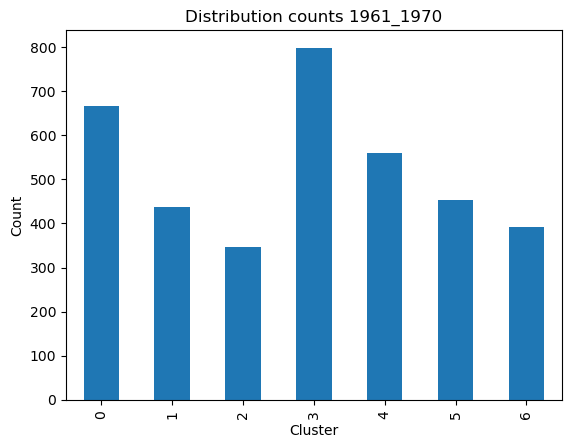

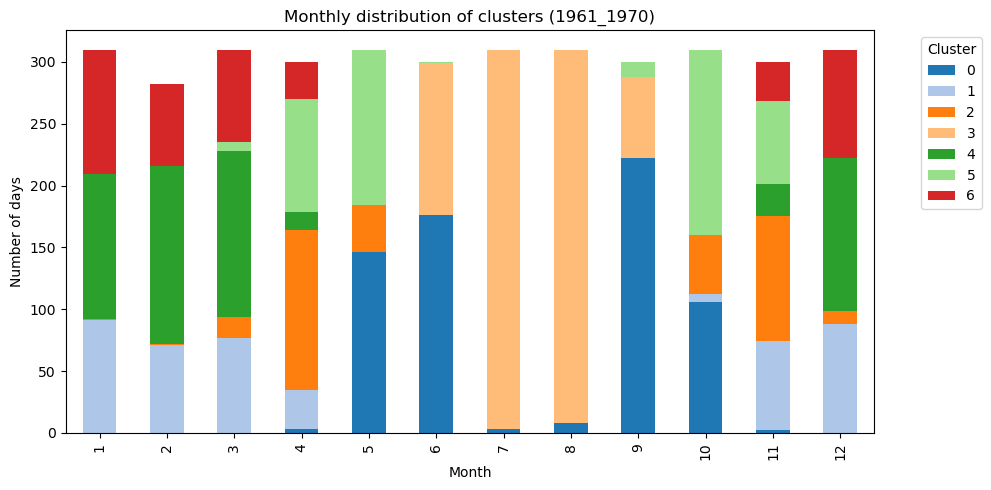

/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead 

Processing t...


     → t: ('time', 'latitude', 'longitude') → (3653, 64521)
Processing z...
     → z: ('time', 'latitude', 'longitude') → (3653, 64521)
     → z: ('time', 'latitude', 'longitude') → (3653, 64521)

Combined matrix shape: (3653, 129042)

Combined matrix shape: (3653, 129042)


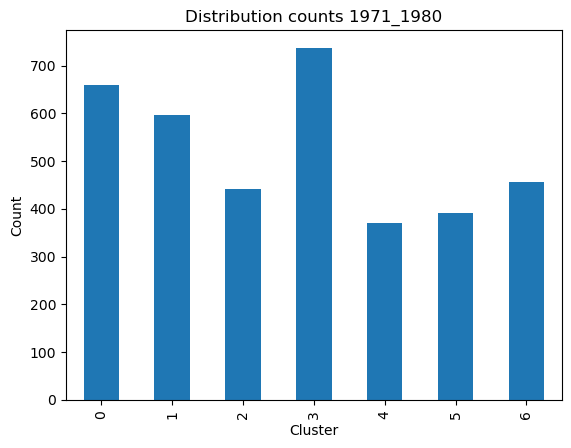

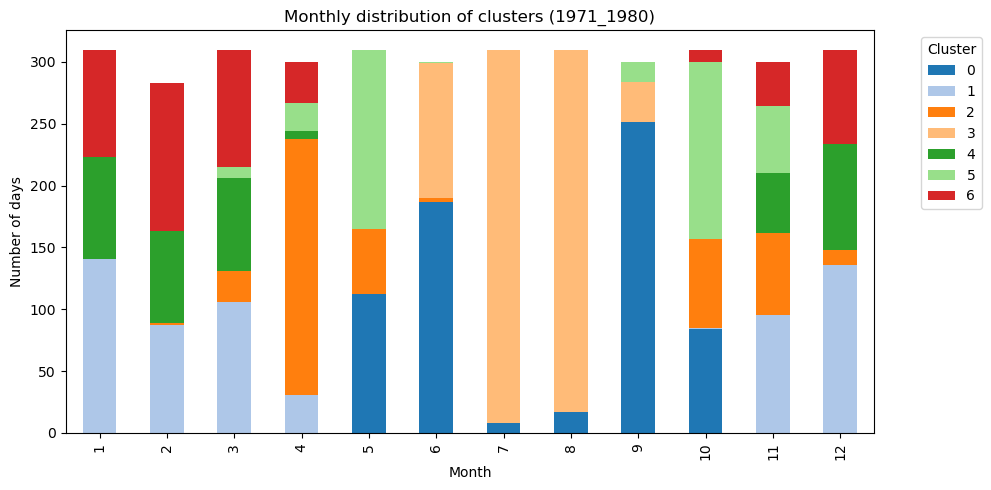

/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead 

Processing t...
     → t: ('time', 'latitude', 'longitude') → (3652, 64521)
Processing z...
     → t: ('time', 'latitude', 'longitude') → (3652, 64521)
Processing z...
     → z: ('time', 'latitude', 'longitude') → (3652, 64521)
     → z: ('time', 'latitude', 'longitude') → (3652, 64521)

Combined matrix shape: (3652, 129042)

Combined matrix shape: (3652, 129042)


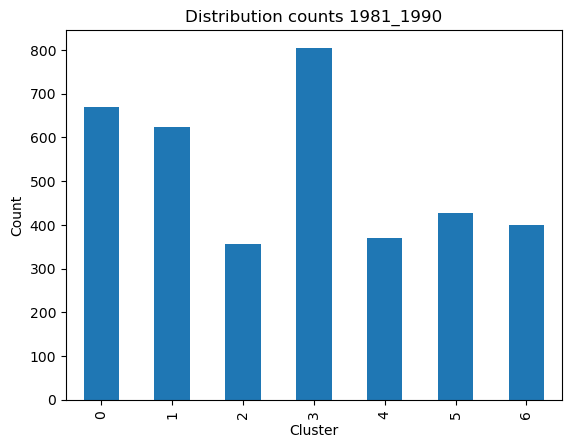

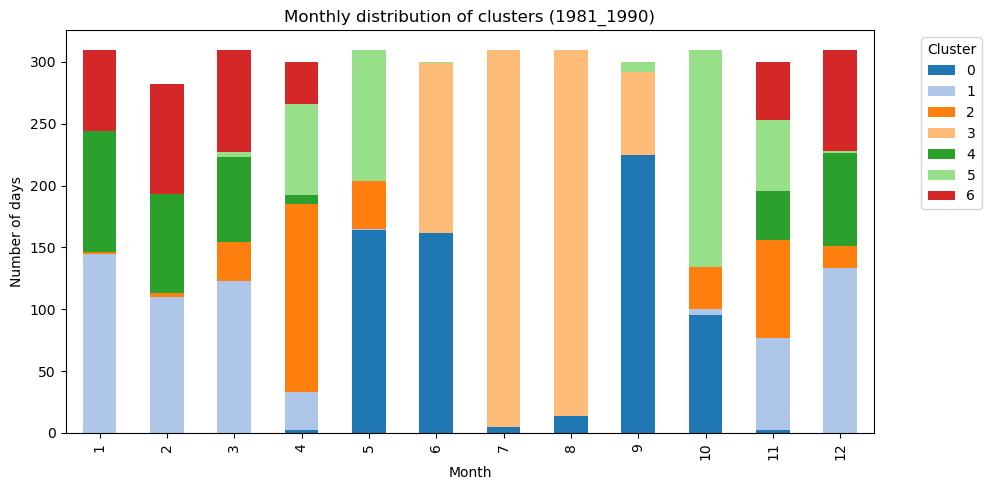

/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead 

Processing t...
     → t: ('time', 'latitude', 'longitude') → (3653, 64521)
Processing z...
     → t: ('time', 'latitude', 'longitude') → (3653, 64521)
Processing z...
     → z: ('time', 'latitude', 'longitude') → (3653, 64521)
     → z: ('time', 'latitude', 'longitude') → (3653, 64521)

Combined matrix shape: (3653, 129042)

Combined matrix shape: (3653, 129042)


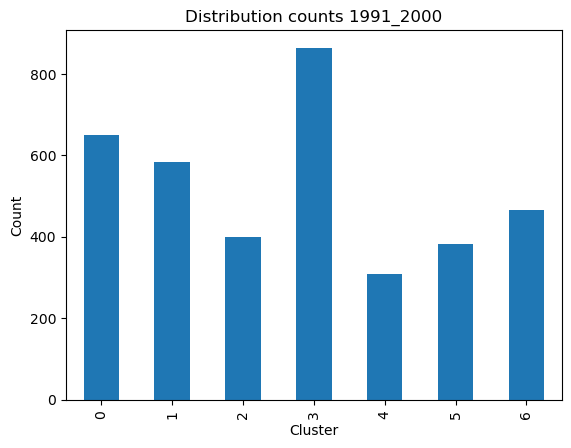

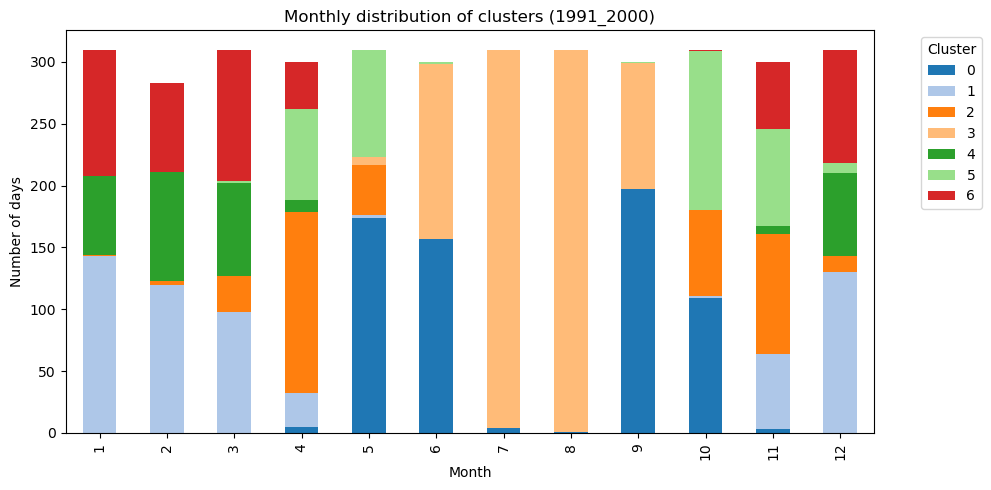

/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead 

Processing t...
     → t: ('time', 'latitude', 'longitude') → (3652, 64521)
Processing z...
     → t: ('time', 'latitude', 'longitude') → (3652, 64521)
Processing z...
     → z: ('time', 'latitude', 'longitude') → (3652, 64521)
     → z: ('time', 'latitude', 'longitude') → (3652, 64521)

Combined matrix shape: (3652, 129042)

Combined matrix shape: (3652, 129042)


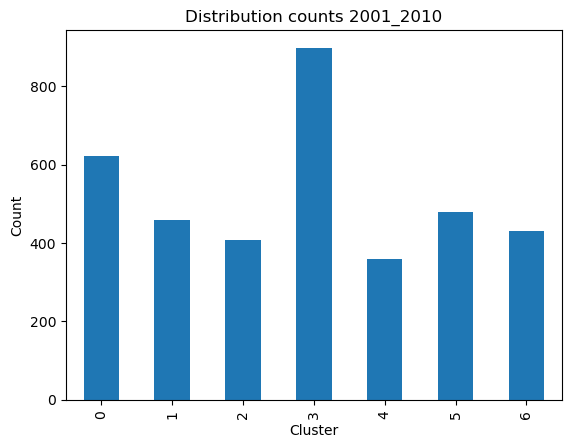

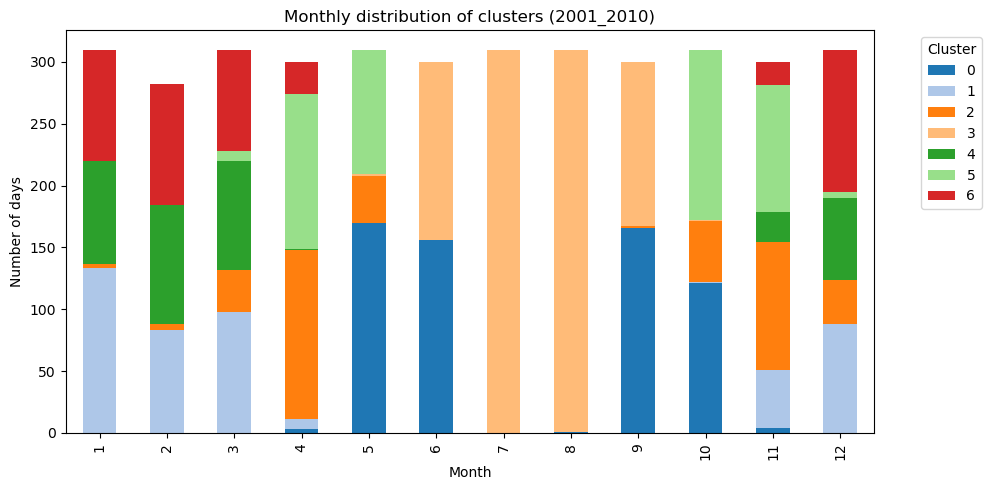

/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/eugenia/miniconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead 

Processing t...
     → t: ('time', 'latitude', 'longitude') → (3653, 64521)
Processing z...
     → t: ('time', 'latitude', 'longitude') → (3653, 64521)
Processing z...
     → z: ('time', 'latitude', 'longitude') → (3653, 64521)
     → z: ('time', 'latitude', 'longitude') → (3653, 64521)

Combined matrix shape: (3653, 129042)

Combined matrix shape: (3653, 129042)


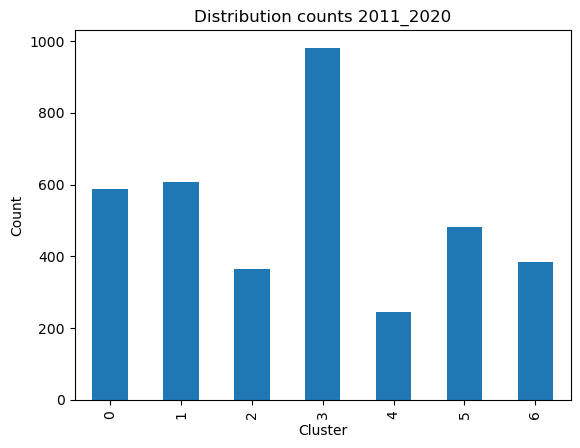

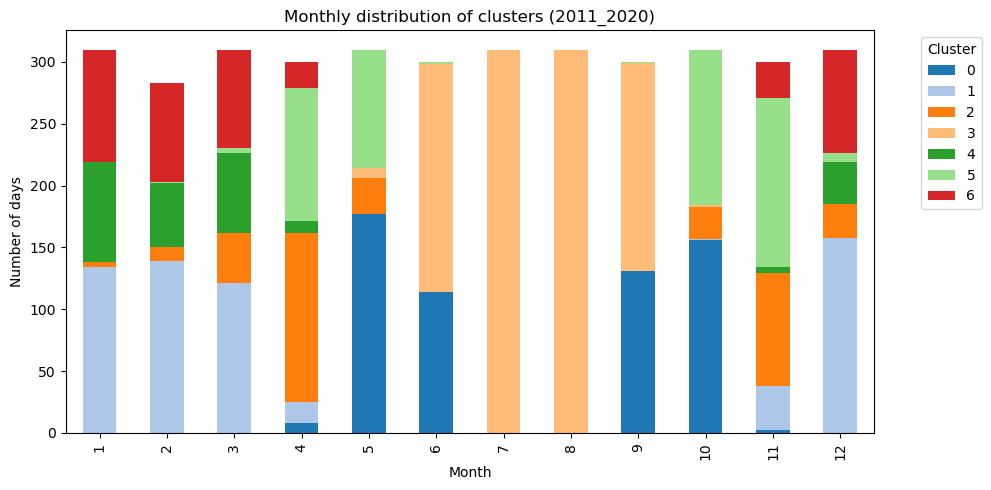

In [3]:


def process_period(grib_path, date_save_path, label_save_path, t_mean, t_std, z_mean, z_std,
    centroids, ipca_path, period_name):

    # Carica dataset
    ds_t = xr.open_dataset(grib_path, engine='cfgrib', filter_by_keys={'shortName': 't'})
    t_850 = ds_t['t']
    t_850 = t_850.reset_coords('isobaricInhPa', drop=True) 

    ds_z = xr.open_dataset(grib_path, engine='cfgrib', filter_by_keys={'shortName': 'z'})
    z_500 = ds_z['z']
    z_500 = z_500.reset_coords('isobaricInhPa', drop=True) 

    ds_filtered = xr.Dataset({
        't': t_850,
        'z': z_500
    })
    # Estrai date e salva
    dates = pd.to_datetime(ds_filtered.time.values)
    np.save(date_save_path, dates)

    # Prepara matrice
    X_matrix, _ = prepare_data_matrix(ds_filtered)

    gc.collect()

    # Separate T e Z
    n_spatial = t_850.shape[1] * t_850.shape[2]  # 201 * 321
    X_t = X_matrix[:, :n_spatial]
    X_z = X_matrix[:, n_spatial:]
    del X_matrix
    gc.collect()

    # Standardize
    X_t_std = (X_t - t_mean) / t_std
    del X_t
    gc.collect()

    X_z_std = (X_z - z_mean) / z_std
    del X_z
    gc.collect()

    # Ricombine
    X_std = np.hstack([X_t_std, X_z_std])
    X_std = X_std.astype(np.float32)
    del X_z_std, X_t_std
    gc.collect()
    

    # PCA
    ipca = joblib.load(ipca_path)
    X_pca = ipca.transform(X_std)
    del X_std
    gc.collect()

    # Assegna cluster
    distances = cdist(X_pca, centroids)
    labels = np.argmin(distances, axis=1)
    np.save(label_save_path, labels)

    # Plot distribuzione cluster
    pd.Series(labels).value_counts().sort_index().plot(kind='bar')
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.title(f"Distribution counts {period_name}")
    plt.show()

    # Plot distribuzione mensile
    months = dates.month
    df = pd.DataFrame({'cluster': labels, 'month': months})
    pivot = pd.crosstab(df['month'], df['cluster'])
    colors = plt.get_cmap('tab20').colors[:len(pivot.columns)]
    ax = pivot.plot(kind='bar', stacked=True, color=colors, figsize=(10,5))
    plt.xlabel("Month")
    plt.ylabel("Number of days")
    plt.title(f"Monthly distribution of clusters ({period_name})")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    return labels, dates


# Load the parameters
t_mean = np.load("Mid_result_to_save/t_mean_60y.npy")
t_std = np.load("Mid_result_to_save/t_std_60y.npy")
z_mean = np.load("Mid_result_to_save/z_mean_60y.npy")
z_std = np.load("Mid_result_to_save/z_std_60y.npy")
centroids = np.load(f"Mid_result_to_save/centroids_k{k_number}_60y.npy")   

# Define the periods to process
periods = [
    {
        "grib_path": "10y/era5_1961_1970_t850_z500.grib",
        "date_save_path": "Mid_result_to_save/dates_1961_1970.npy",
        "label_save_path": "Mid_result_to_save/labels_1961_1970.npy",
        "period_name": "1961_1970"
    },
    {
        "grib_path": "10y/era5_1971_1980_t850_z500.grib",
        "date_save_path": "Mid_result_to_save/dates_1971_1980.npy",
        "label_save_path": "Mid_result_to_save/labels_1971_1980.npy",
        "period_name": "1971_1980"
    },
    {
        "grib_path": "10y/era5_1981_1990_t850_z500.grib",
        "date_save_path": "Mid_result_to_save/dates_1981_1990.npy",
        "label_save_path": "Mid_result_to_save/labels_1981_1990.npy",
        "period_name": "1981_1990"
    },
    {
        "grib_path": "10y/era5_1991_2000_t850_z500.grib",
        "date_save_path": "Mid_result_to_save/dates_1991_2000.npy",
        "label_save_path": "Mid_result_to_save/labels_1991_2000.npy",
        "period_name": "1991_2000"
    },
    {
        "grib_path": "10y/era5_2001_2010_t850_z500.grib",
        "date_save_path": "Mid_result_to_save/dates_2001_2010.npy",
        "label_save_path": "Mid_result_to_save/labels_2001_2010.npy",
        "period_name": "2001_2010"
    },
    {
        "grib_path": "10y/era5_2011_2020_t850_z500.grib",
        "date_save_path": "Mid_result_to_save/dates_2011_2020.npy",
        "label_save_path": "Mid_result_to_save/labels_2011_2020.npy",
        "period_name": "2011_2020"
    }
]

# Save results for all periods
results = []
for period in periods:
    labels, dates = process_period(
        grib_path=period["grib_path"],
        date_save_path=period["date_save_path"],
        label_save_path=period["label_save_path"],
        t_mean=t_mean,
        t_std=t_std,
        z_mean=z_mean,
        z_std=z_std,
        centroids=centroids,
        ipca_path='Mid_result_to_save/ipca_60y.pkl',
        period_name=period["period_name"]
    )
    results.append({"labels": labels, "dates": dates, "period": period["period_name"]})


### Analysis and comparing between the two periods

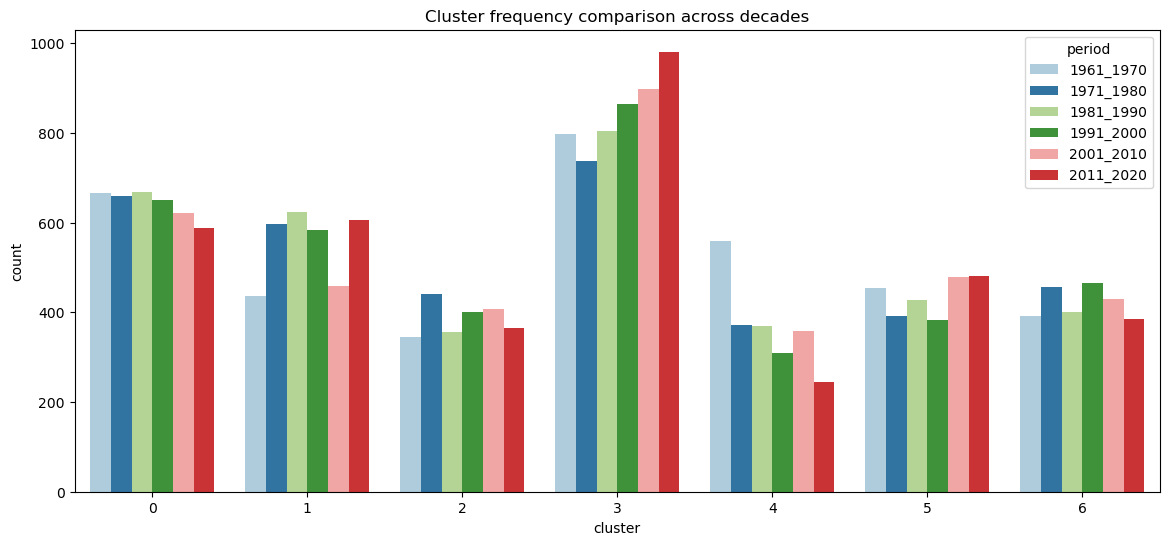

In [4]:
#Compare cluster distributions across decades
period_names = [p['period_name'] for p in periods]
dfs = []

for period in period_names:
    labels = np.load(f"Mid_result_to_save/labels_{period}.npy")
    dates = np.load(f"Mid_result_to_save/dates_{period}.npy")  
    months = pd.to_datetime(dates).month
    years = pd.to_datetime(dates).year
    df = pd.DataFrame({
        'period': [period] * len(labels),
        'cluster': labels,
        'month': months,
        'year': years
    })
    dfs.append(df)

# Unify all dataframes
df_all = pd.concat(dfs, ignore_index=True)

# Plot
plt.figure(figsize=(14,6))
sns.countplot(data=df_all, x='cluster', hue='period', palette="Paired")
plt.title("Cluster frequency comparison across decades")
plt.show()

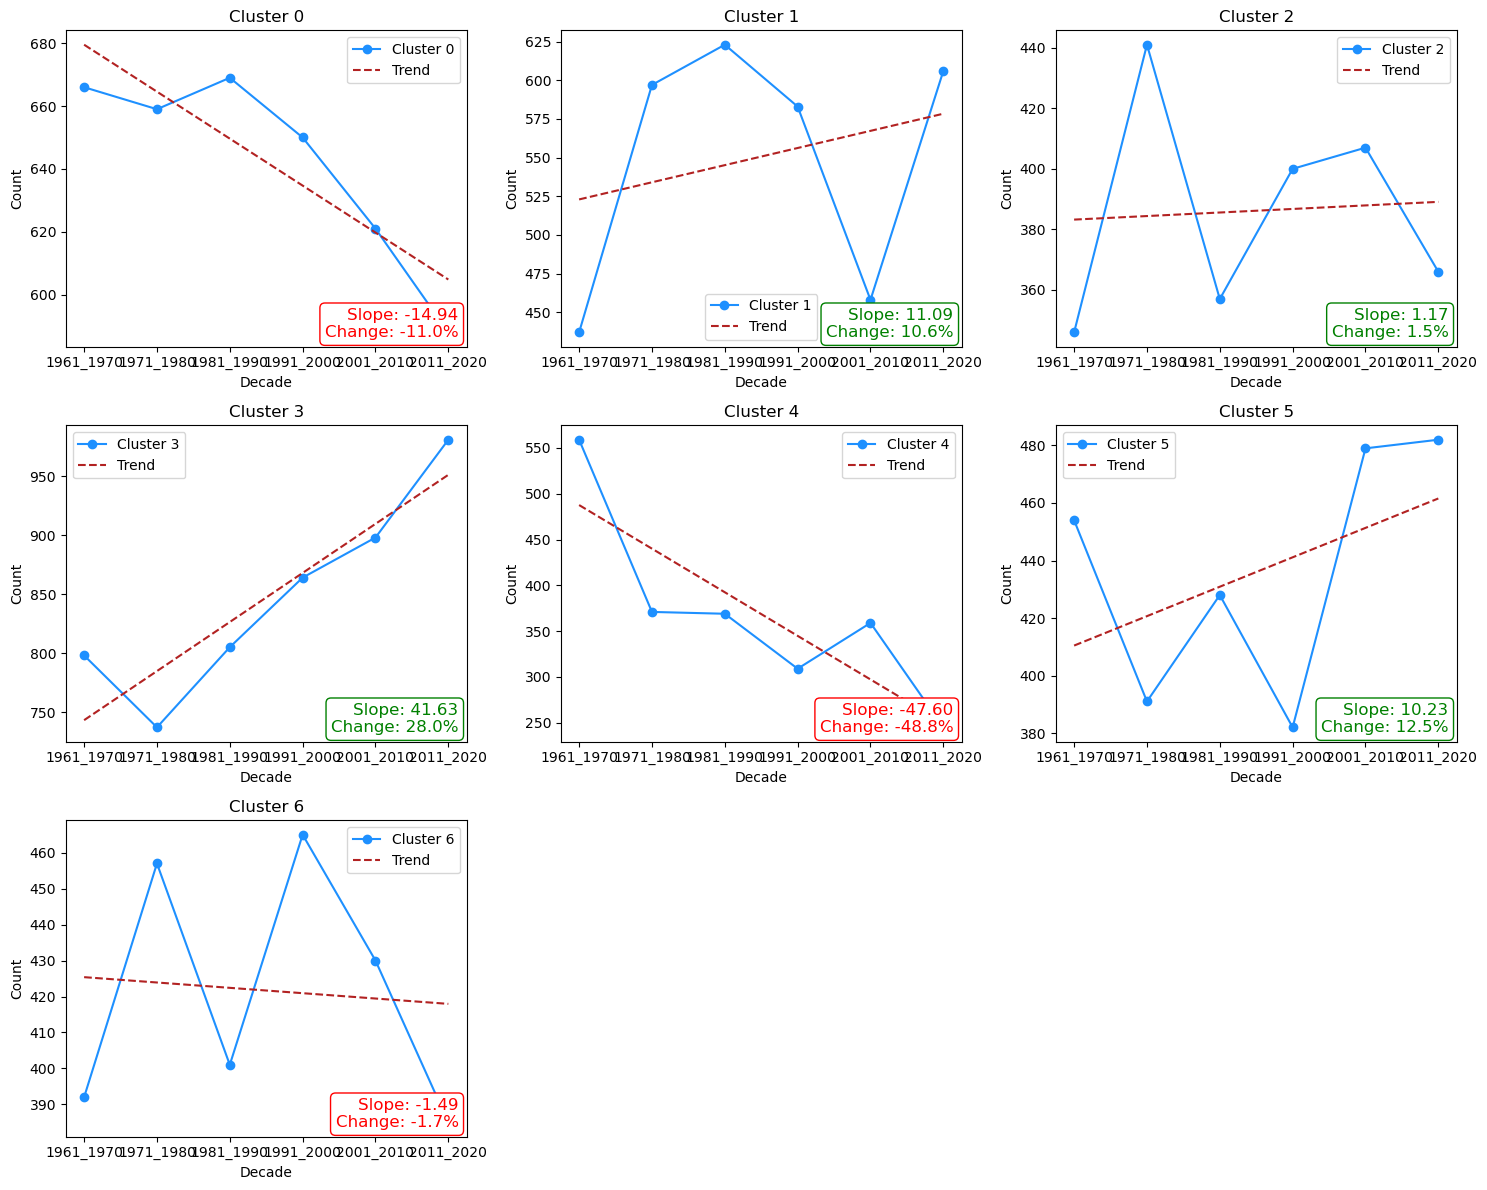

In [5]:
# Plot trends for significant clusters
significant_clusters = range(k_number)    
decades = sorted(df_all['period'].unique())
n_clusters = len(significant_clusters)
n_cols = 3
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for idx, k in enumerate(significant_clusters):
    counts = []
    for decade in decades:
        count = (df_all[(df_all['cluster'] == k) & (df_all['period'] == decade)].shape[0])
        counts.append(count)
    ax = axes[idx]
    ax.plot(decades, counts, marker='o', color='dodgerblue', label=f'Cluster {k}')
    # Linear regression
    X = np.arange(len(decades)).reshape(-1,1)
    reg = LinearRegression().fit(X, counts)
    y_pred = reg.predict(X)
    ax.plot(decades, y_pred, color='firebrick', linestyle='--', label='Trend')
    # Statistics
    slope = reg.coef_[0]
    perc_change = 100 * (y_pred[-1] - y_pred[0]) / y_pred[0] if y_pred[0] != 0 else np.nan
    color = 'green' if perc_change > 0 else 'red'
    label_text = f"Slope: {slope:.2f}\nChange: {perc_change:.1f}%"
    ax.text(0.98, 0.02, label_text, color=color, fontsize=12, ha='right', va='bottom', transform=ax.transAxes,
            bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3'))
    ax.set_title(f'Cluster {k}')
    ax.set_xlabel('Decade')
    ax.set_ylabel('Count')
    ax.legend()

# Remove empty subplots
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Same graphs but per year

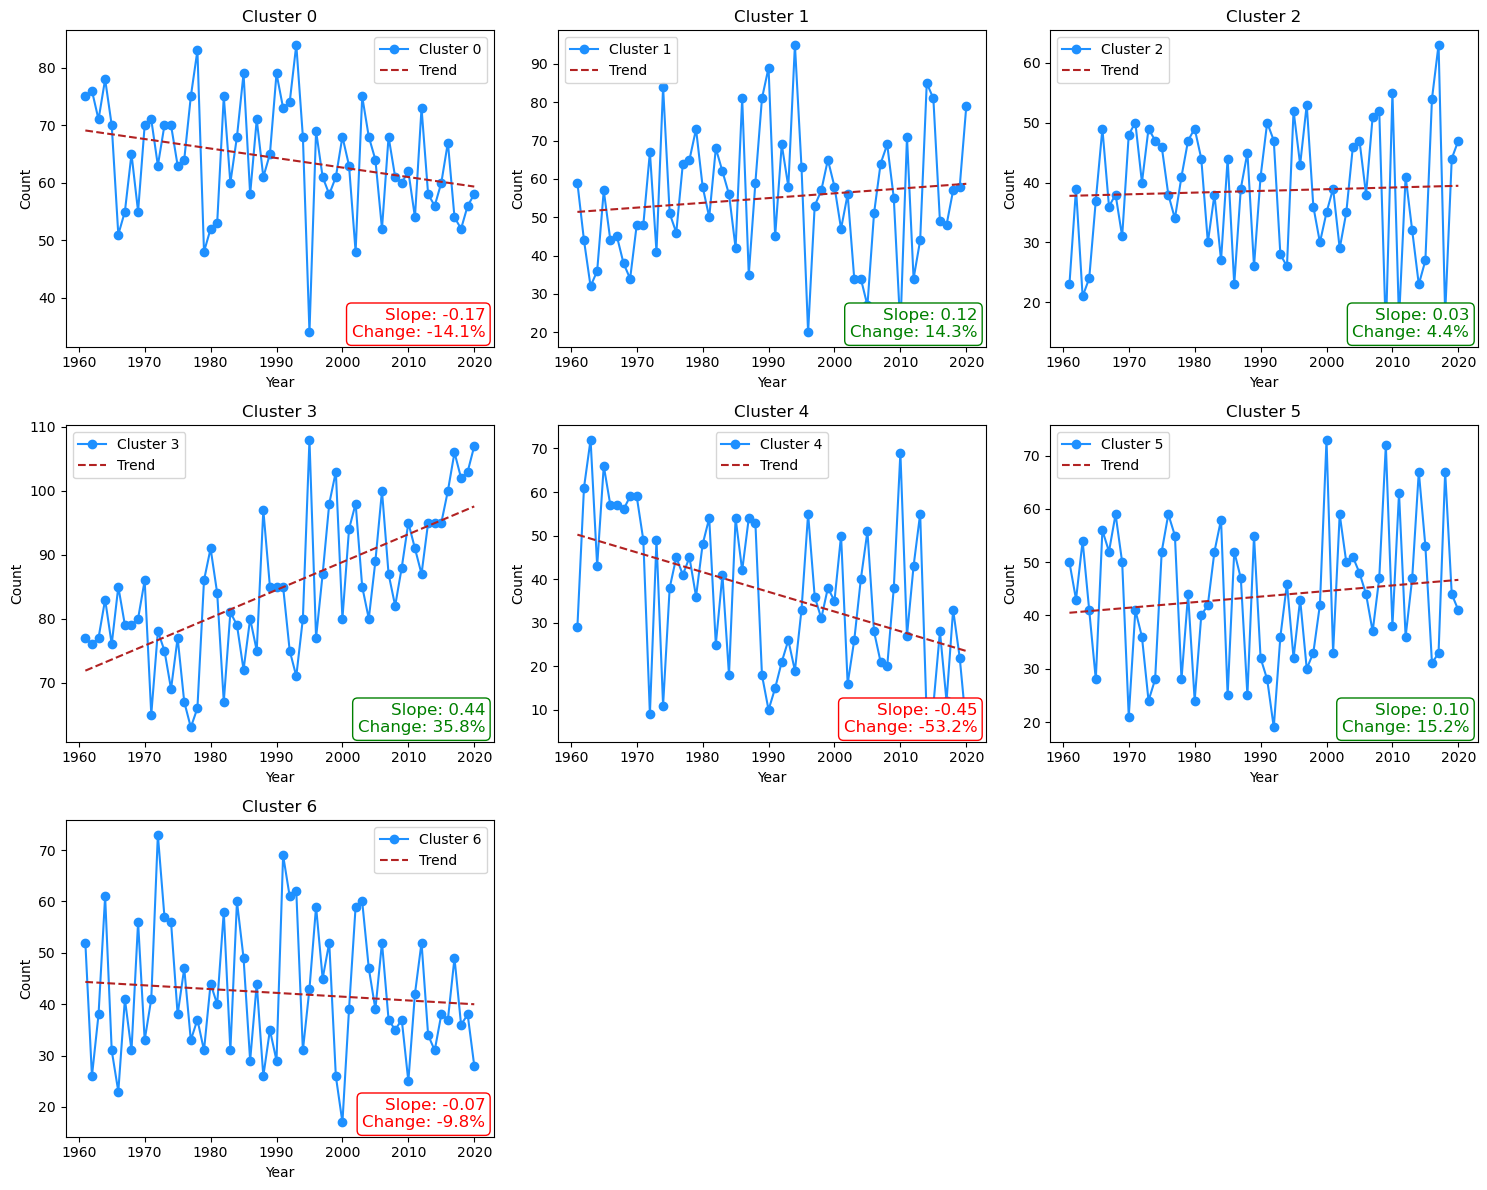

In [6]:
years = sorted(df_all['year'].unique())
n_clusters = df_all['cluster'].nunique()
n_cols = 3
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for idx, k in enumerate(range(n_clusters)):
    counts = []
    for year in years:
        count = (df_all[(df_all['cluster'] == k) & (df_all['year'] == year)].shape[0])
        counts.append(count)
    ax = axes[idx]
    ax.plot(years, counts, marker='o', color='dodgerblue', label=f'Cluster {k}')
    # Linear regression
    X = np.arange(len(years)).reshape(-1,1)
    reg = LinearRegression().fit(X, counts)
    y_pred = reg.predict(X)
    ax.plot(years, y_pred, color='firebrick', linestyle='--', label='Trend')
    slope = reg.coef_[0]
    perc_change = 100 * (y_pred[-1] - y_pred[0]) / y_pred[0] if y_pred[0] != 0 else np.nan
    color = 'green' if perc_change > 0 else 'red'
    label_text = f"Slope: {slope:.2f}\nChange: {perc_change:.1f}%"
    ax.text(0.98, 0.02, label_text, color=color, fontsize=12, ha='right', va='bottom', transform=ax.transAxes,
            bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3'))
    ax.set_title(f'Cluster {k}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.legend()

for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Statistical Robustness 



In [7]:
from scipy import stats

def calculate_trend_stats(years, counts):
    """
    Calculate p-value and R-squared for linear trend
    """
    X_idx = np.arange(len(years)).reshape(-1, 1)
    y = np.array(counts)
    
    # Linear regression
    reg = LinearRegression().fit(X_idx, y)
    y_pred = reg.predict(X_idx)
    slope = reg.coef_[0]
    
    # R-squared
    r_squared = reg.score(X_idx, y)
    
    # Calculate t-statistic and p-value for slope
    n = len(y)
    residuals = y - y_pred
    mse = np.sum(residuals**2) / (n - 2)
    var_slope = mse / np.sum((X_idx.flatten() - X_idx.mean())**2)
    t_stat = slope / np.sqrt(var_slope)
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))
    
    return slope, p_value, r_squared

# Calculate stats for all clusters
years = sorted(df_all['year'].unique())
trend_stats = []

for k in range(df_all['cluster'].nunique()):
    counts = []
    for year in years:
        count = (df_all[(df_all['cluster'] == k) & (df_all['year'] == year)].shape[0])
        counts.append(count)
    
    slope, p_value, r_squared = calculate_trend_stats(years, counts)
    
    trend_stats.append({
        'Cluster': k,
        'Slope': slope,
        'P_value': p_value,
        'R_squared': r_squared,
        'Significant': p_value < 0.05
    })

# Create DataFrame
df_stats = pd.DataFrame(trend_stats)
print("TREND STATISTICS SUMMARY")
print("="*50)
print(df_stats.round(4))

TREND STATISTICS SUMMARY
   Cluster   Slope  P_value  R_squared  Significant
0        0 -0.1653   0.0210     0.0884         True
1        1  0.1242   0.3272     0.0166        False
2        2  0.0284   0.7282     0.0021        False
3        3  0.4355   0.0000     0.4579         True
4        4 -0.4526   0.0002     0.2084         True
5        5  0.1046   0.2842     0.0197        False
6        6 -0.0737   0.4364     0.0105        False



STATISTICALLY SIGNIFICANT TRENDS (p < 0.05)
   Cluster   Slope  P_value  R_squared  Significant
0        0 -0.1653   0.0210     0.0884         True
3        3  0.4355   0.0000     0.4579         True
4        4 -0.4526   0.0002     0.2084         True


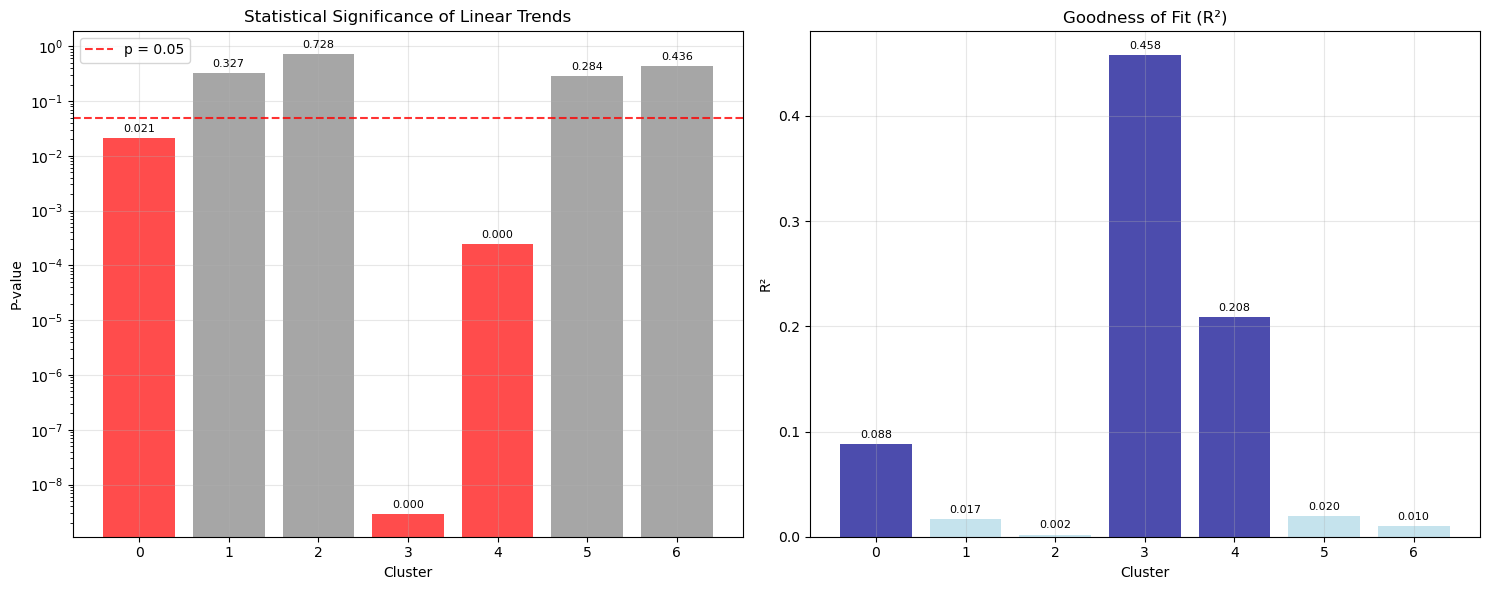

In [8]:
# Filter significant trends
significant_trends = df_stats[df_stats['Significant'] == True].copy()

print("\nSTATISTICALLY SIGNIFICANT TRENDS (p < 0.05)")
print("="*50)
if len(significant_trends) > 0:
    print(significant_trends.round(4))
else:
    print("No statistically significant trends found")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: P-values
ax1 = axes[0]
colors = ['red' if p < 0.05 else 'gray' for p in df_stats['P_value']]
bars1 = ax1.bar(df_stats['Cluster'], df_stats['P_value'], color=colors, alpha=0.7)
ax1.axhline(y=0.05, color='red', linestyle='--', alpha=0.8, label='p = 0.05')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('P-value')
ax1.set_title('Statistical Significance of Linear Trends')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add p-value labels on bars
for bar, p_val in zip(bars1, df_stats['P_value']):
    height = bar.get_height()
    ax1.annotate(f'{p_val:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# Plot 2: R-squared
ax2 = axes[1]
colors2 = ['darkblue' if p < 0.05 else 'lightblue' for p in df_stats['P_value']]
bars2 = ax2.bar(df_stats['Cluster'], df_stats['R_squared'], color=colors2, alpha=0.7)
ax2.set_xlabel('Cluster')
ax2.set_ylabel('R²')
ax2.set_title('Goodness of Fit (R²)')
ax2.grid(True, alpha=0.3)

# Add R² labels on bars
for bar, r2 in zip(bars2, df_stats['R_squared']):
    height = bar.get_height()
    ax2.annotate(f'{r2:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Save results
df_stats.to_csv(f"Mid_result_to_save/trend_statistics_k{k_number}.csv", index=False)

___________________________11/09/2025

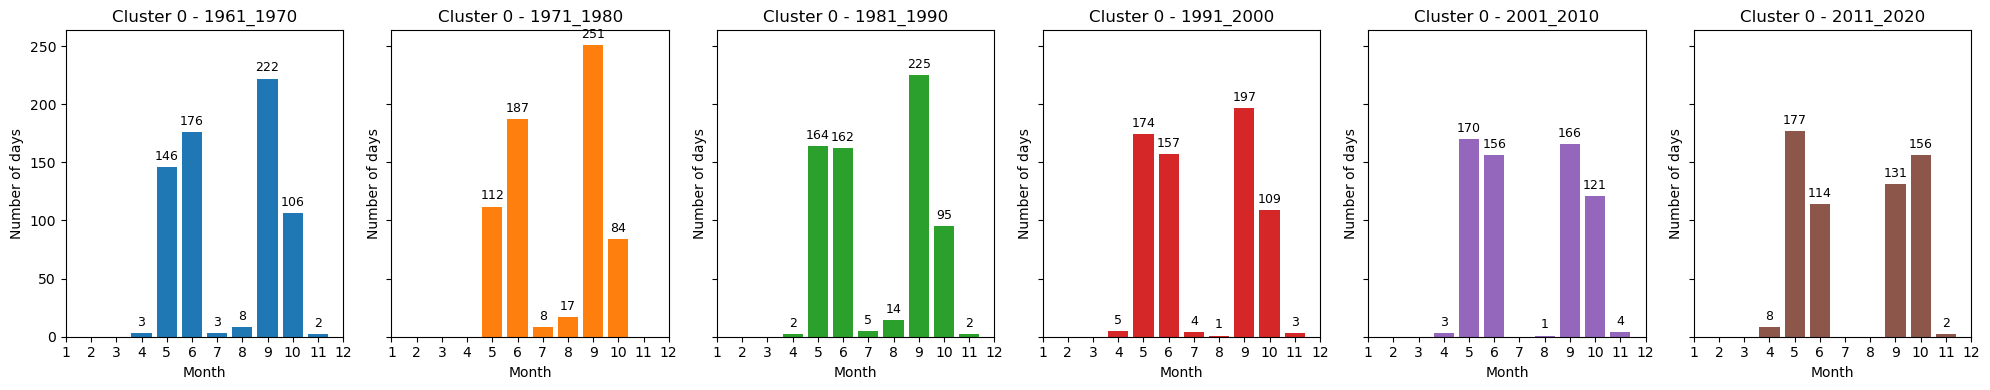

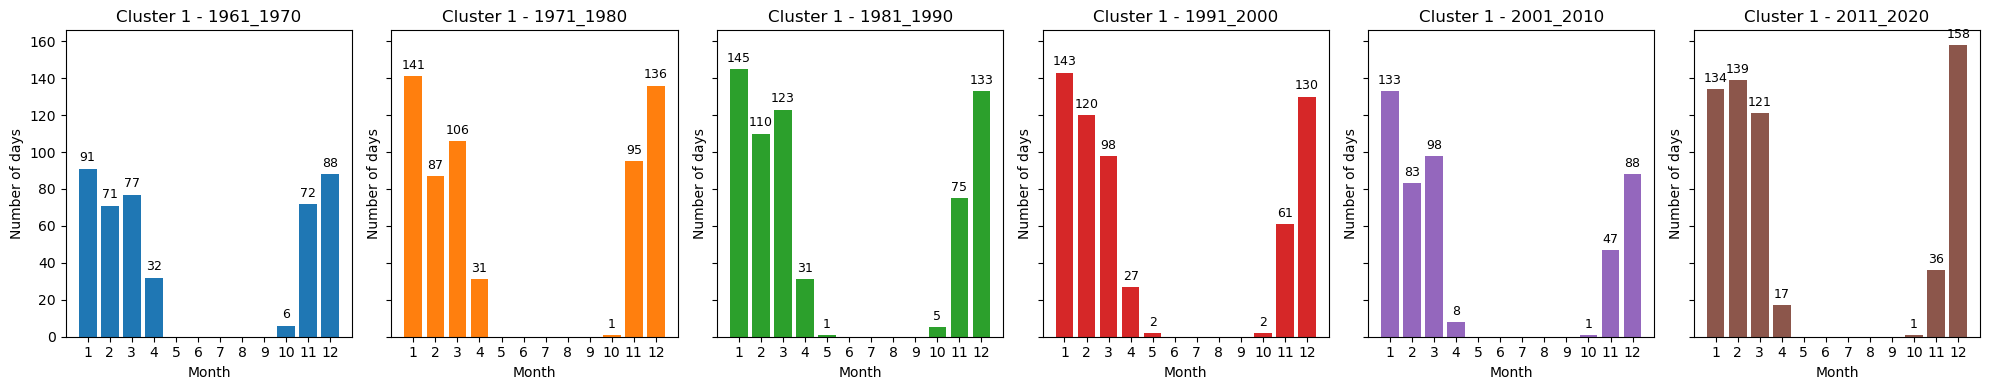

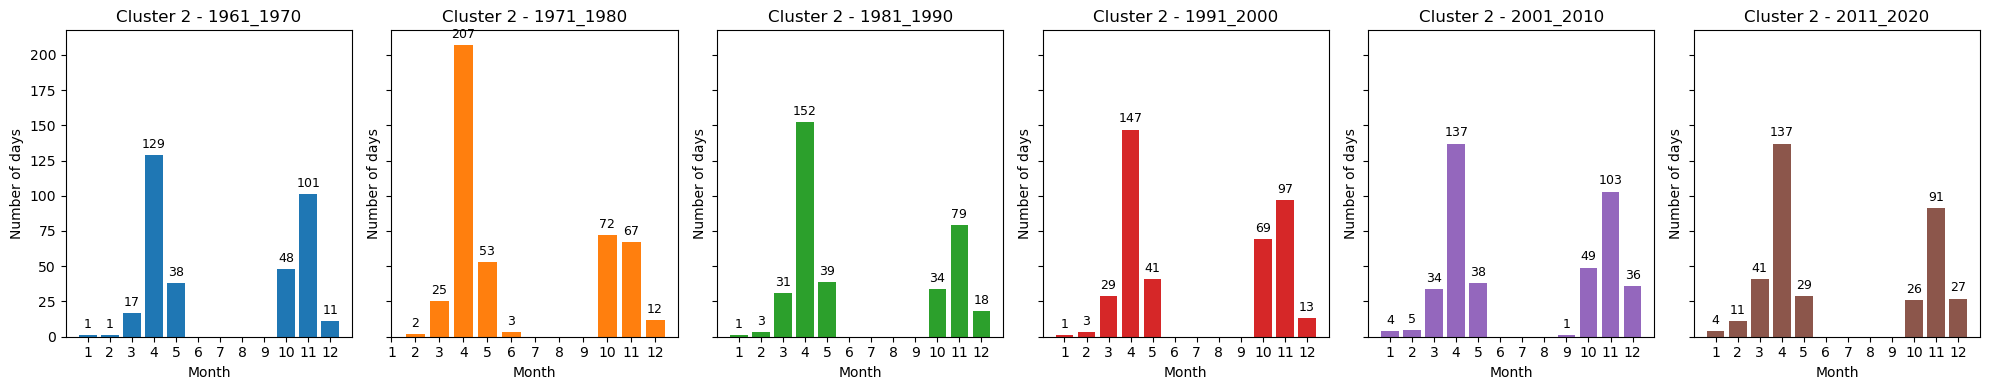

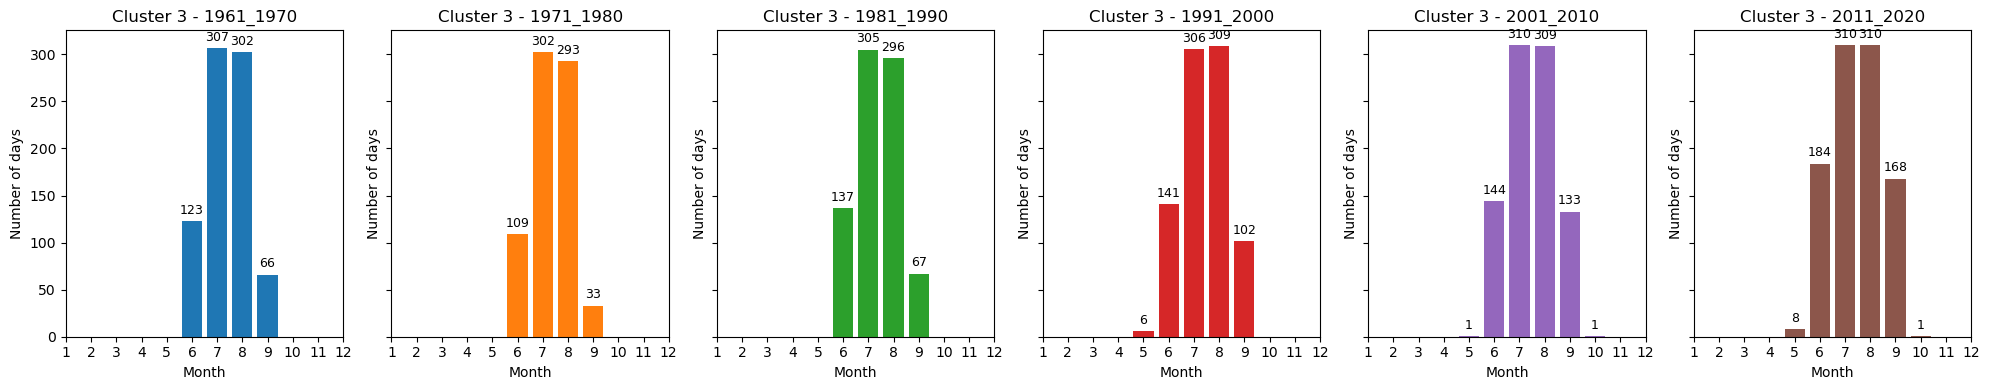

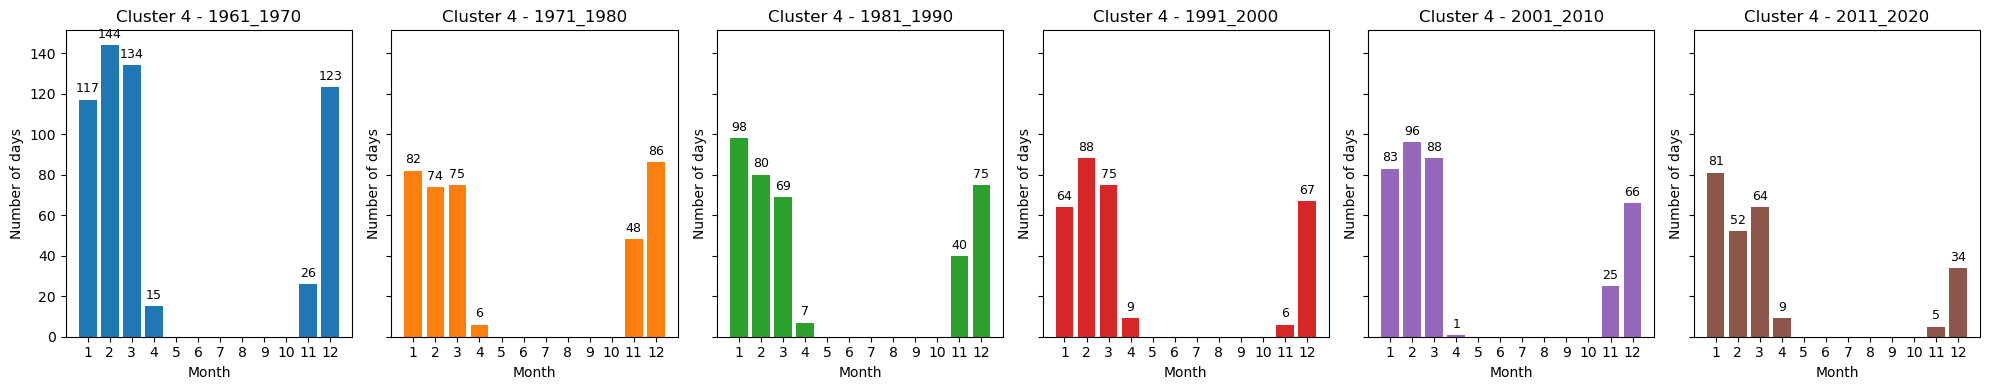

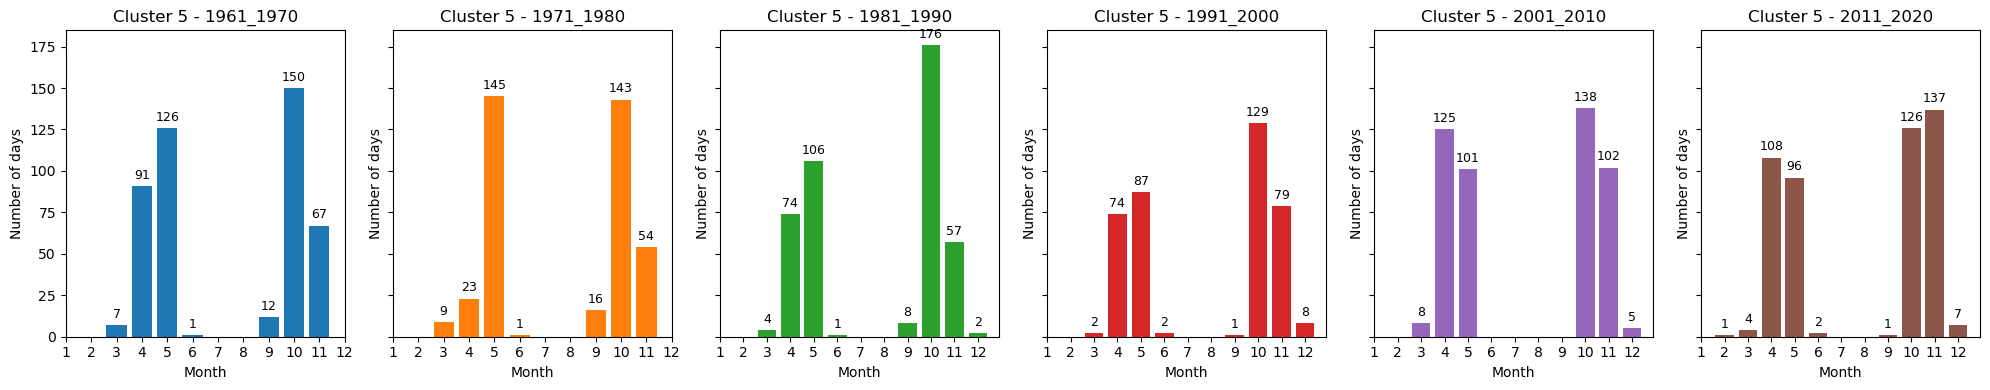

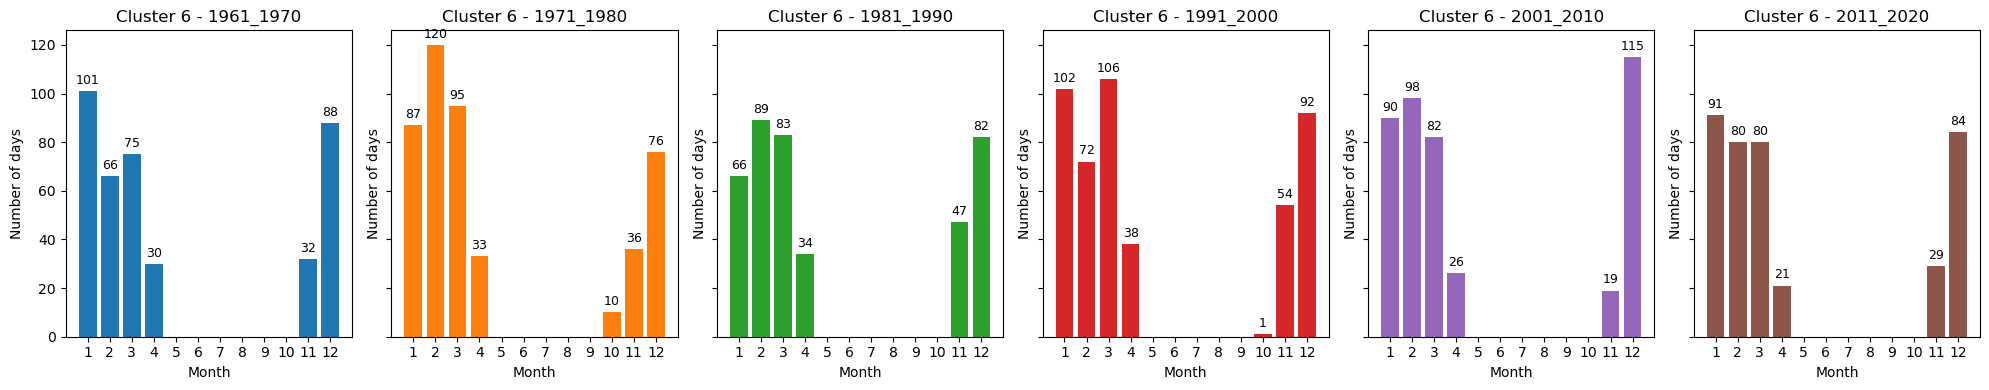

In [9]:
# Monthly distribution per cluster and period
n_clusters = df_all['cluster'].nunique()

colors = sns.color_palette("tab10", n_colors=len(period_names))

for cluster in range(n_clusters):
    fig, axes = plt.subplots(1, len(period_names), figsize=(20, 4), sharey=True)
    for i, period in enumerate(period_names):
        subset = df_all[(df_all['cluster'] == cluster) & (df_all['period'] == period)]
        counts = subset['month'].value_counts().sort_index()
        total_count = counts.sum()
        bars = axes[i].bar(counts.index, counts.values, color=colors[i])
        axes[i].set_title(f'Cluster {cluster} - {period}')
        axes[i].set_xlabel('Month')
        axes[i].set_ylabel('Number of days')
        axes[i].set_xticks(range(1, 13))
        # Aggiungi il numero sopra ogni barra
        for bar in bars:
            height = bar.get_height()
            axes[i].annotate(f'{int(height)}',
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 3),
                             textcoords="offset points",
                             ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

#### Cross tab   

In [10]:
# Create a pivot table for better visualization
pivot_table = pd.crosstab(
    [df_all['period'], df_all['month']],
    df_all['cluster']
)

print(pivot_table)
pivot_table.to_csv(f"Mid_result_to_save/tab_period_month_k{k_number}.csv")

cluster            0    1    2    3    4    5    6
period    month                                   
1961_1970 1        0   91    1    0  117    0  101
          2        0   71    1    0  144    0   66
          3        0   77   17    0  134    7   75
          4        3   32  129    0   15   91   30
          5      146    0   38    0    0  126    0
...              ...  ...  ...  ...  ...  ...  ...
2011_2020 8        0    0    0  310    0    0    0
          9      131    0    0  168    0    1    0
          10     156    1   26    1    0  126    0
          11       2   36   91    0    5  137   29
          12       0  158   27    0   34    7   84

[72 rows x 7 columns]


cluster      0   1   2   3   4   5   6
year month                            
1961 1       0  14   0   0   5   0  12
     2       0  12   0   0   0   0  16
     3       0   8   1   0  10   0  12
     4       0   6   7   0   3  14   0
     5      23   0   0   0   0   8   0
...         ..  ..  ..  ..  ..  ..  ..
2020 8       0   0   0  31   0   0   0
     9      10   0   0  20   0   0   0
     10     16   0   3   1   0  11   0
     11      1   3   4   0   0  17   5
     12      0   9  12   0   1   4   5

[720 rows x 7 columns]


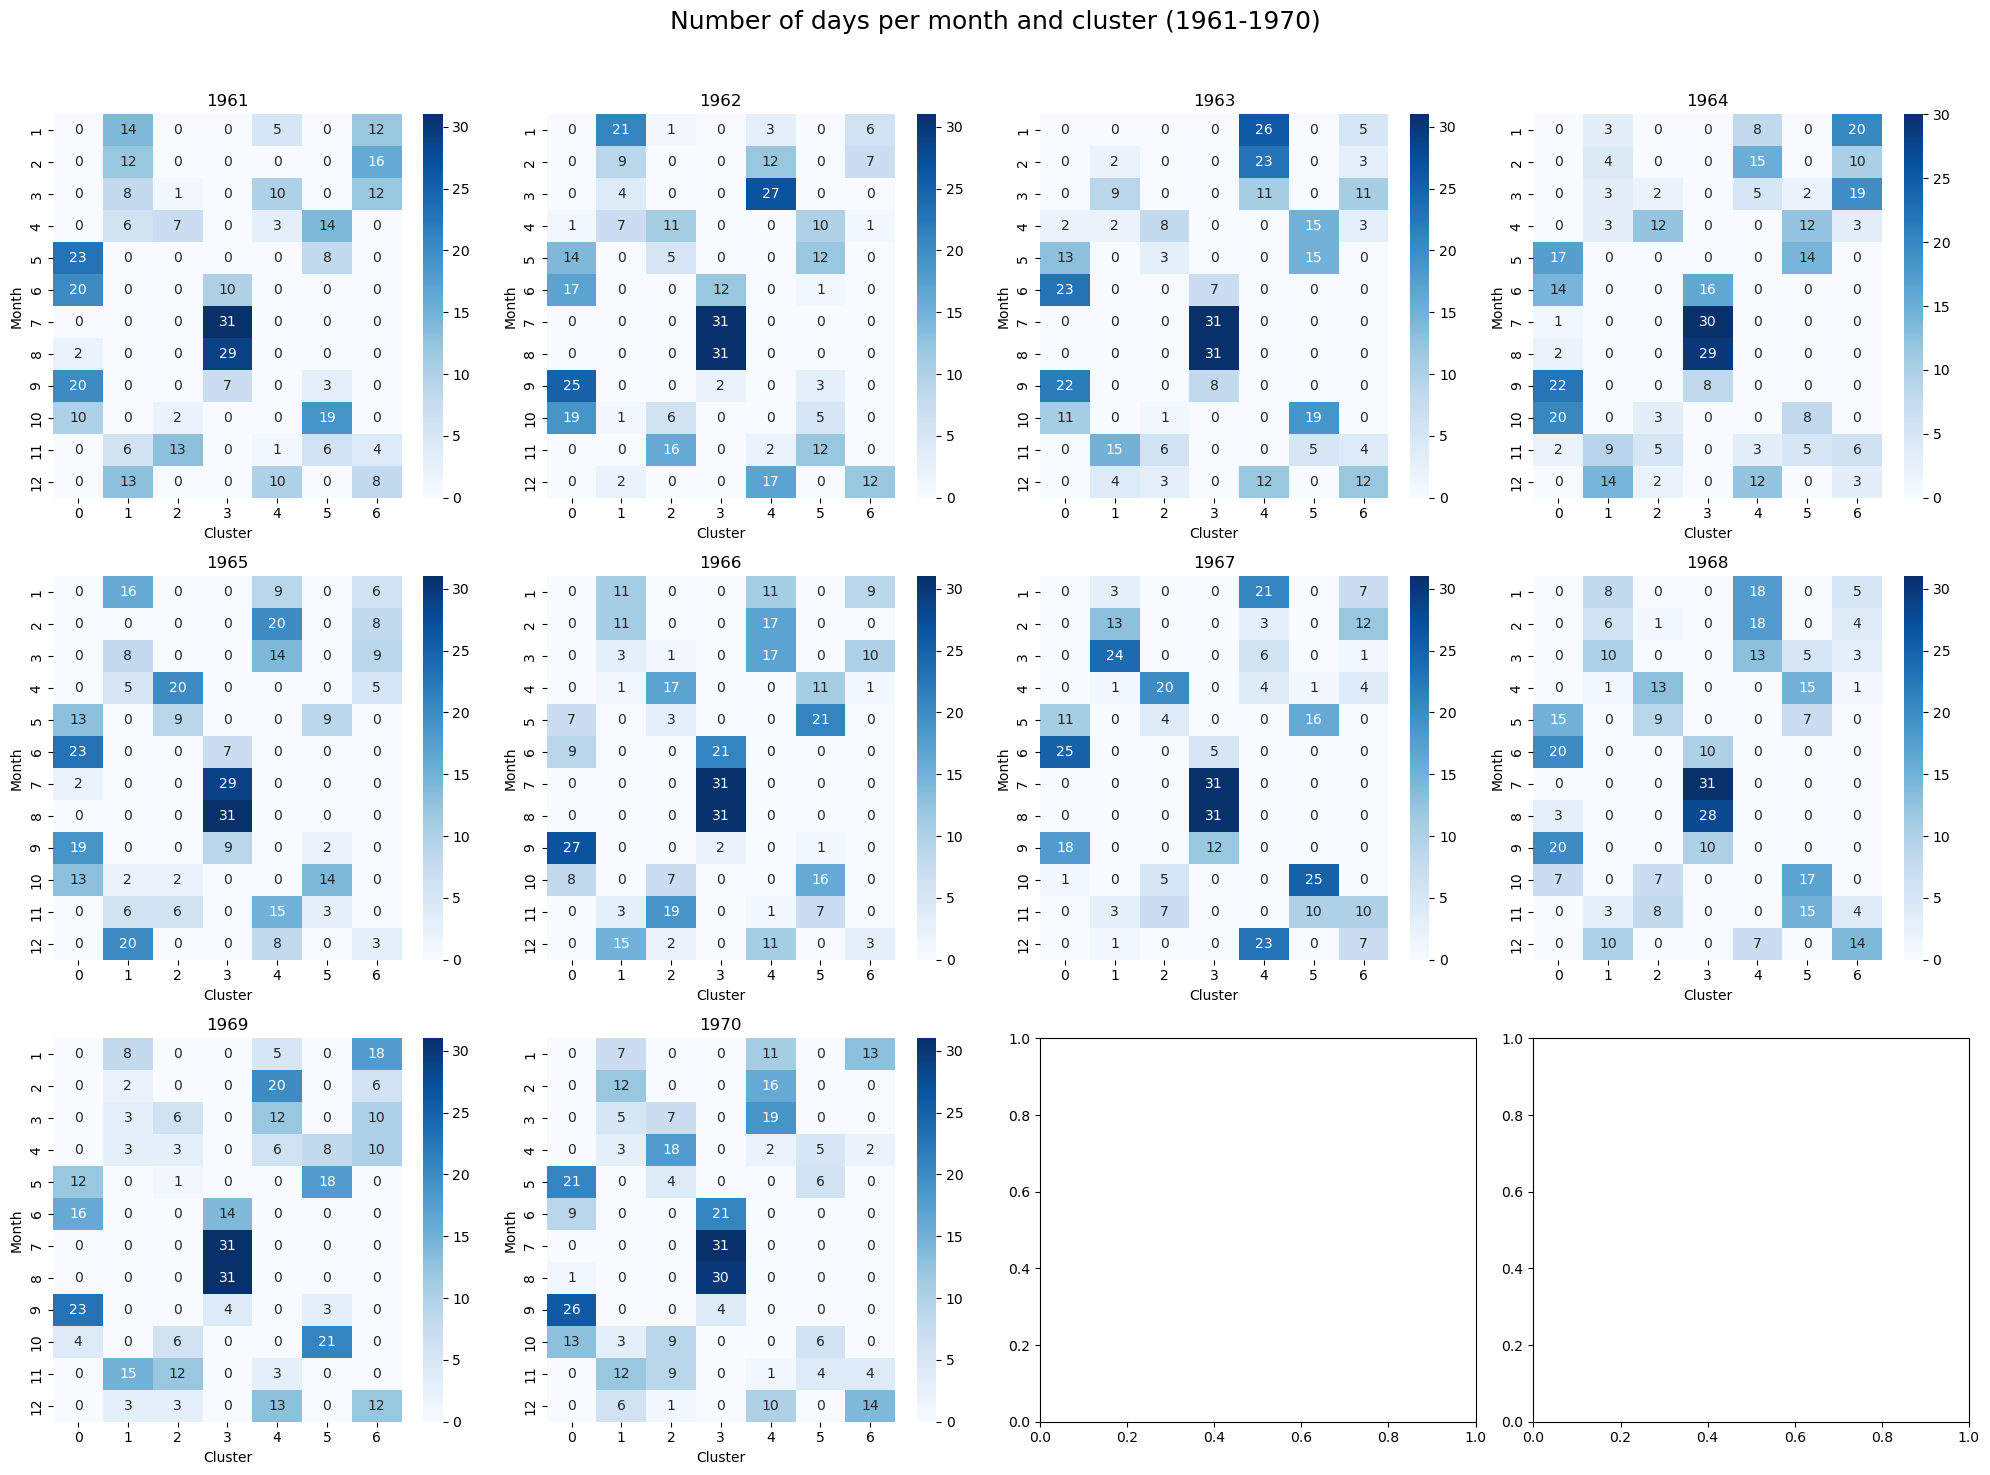

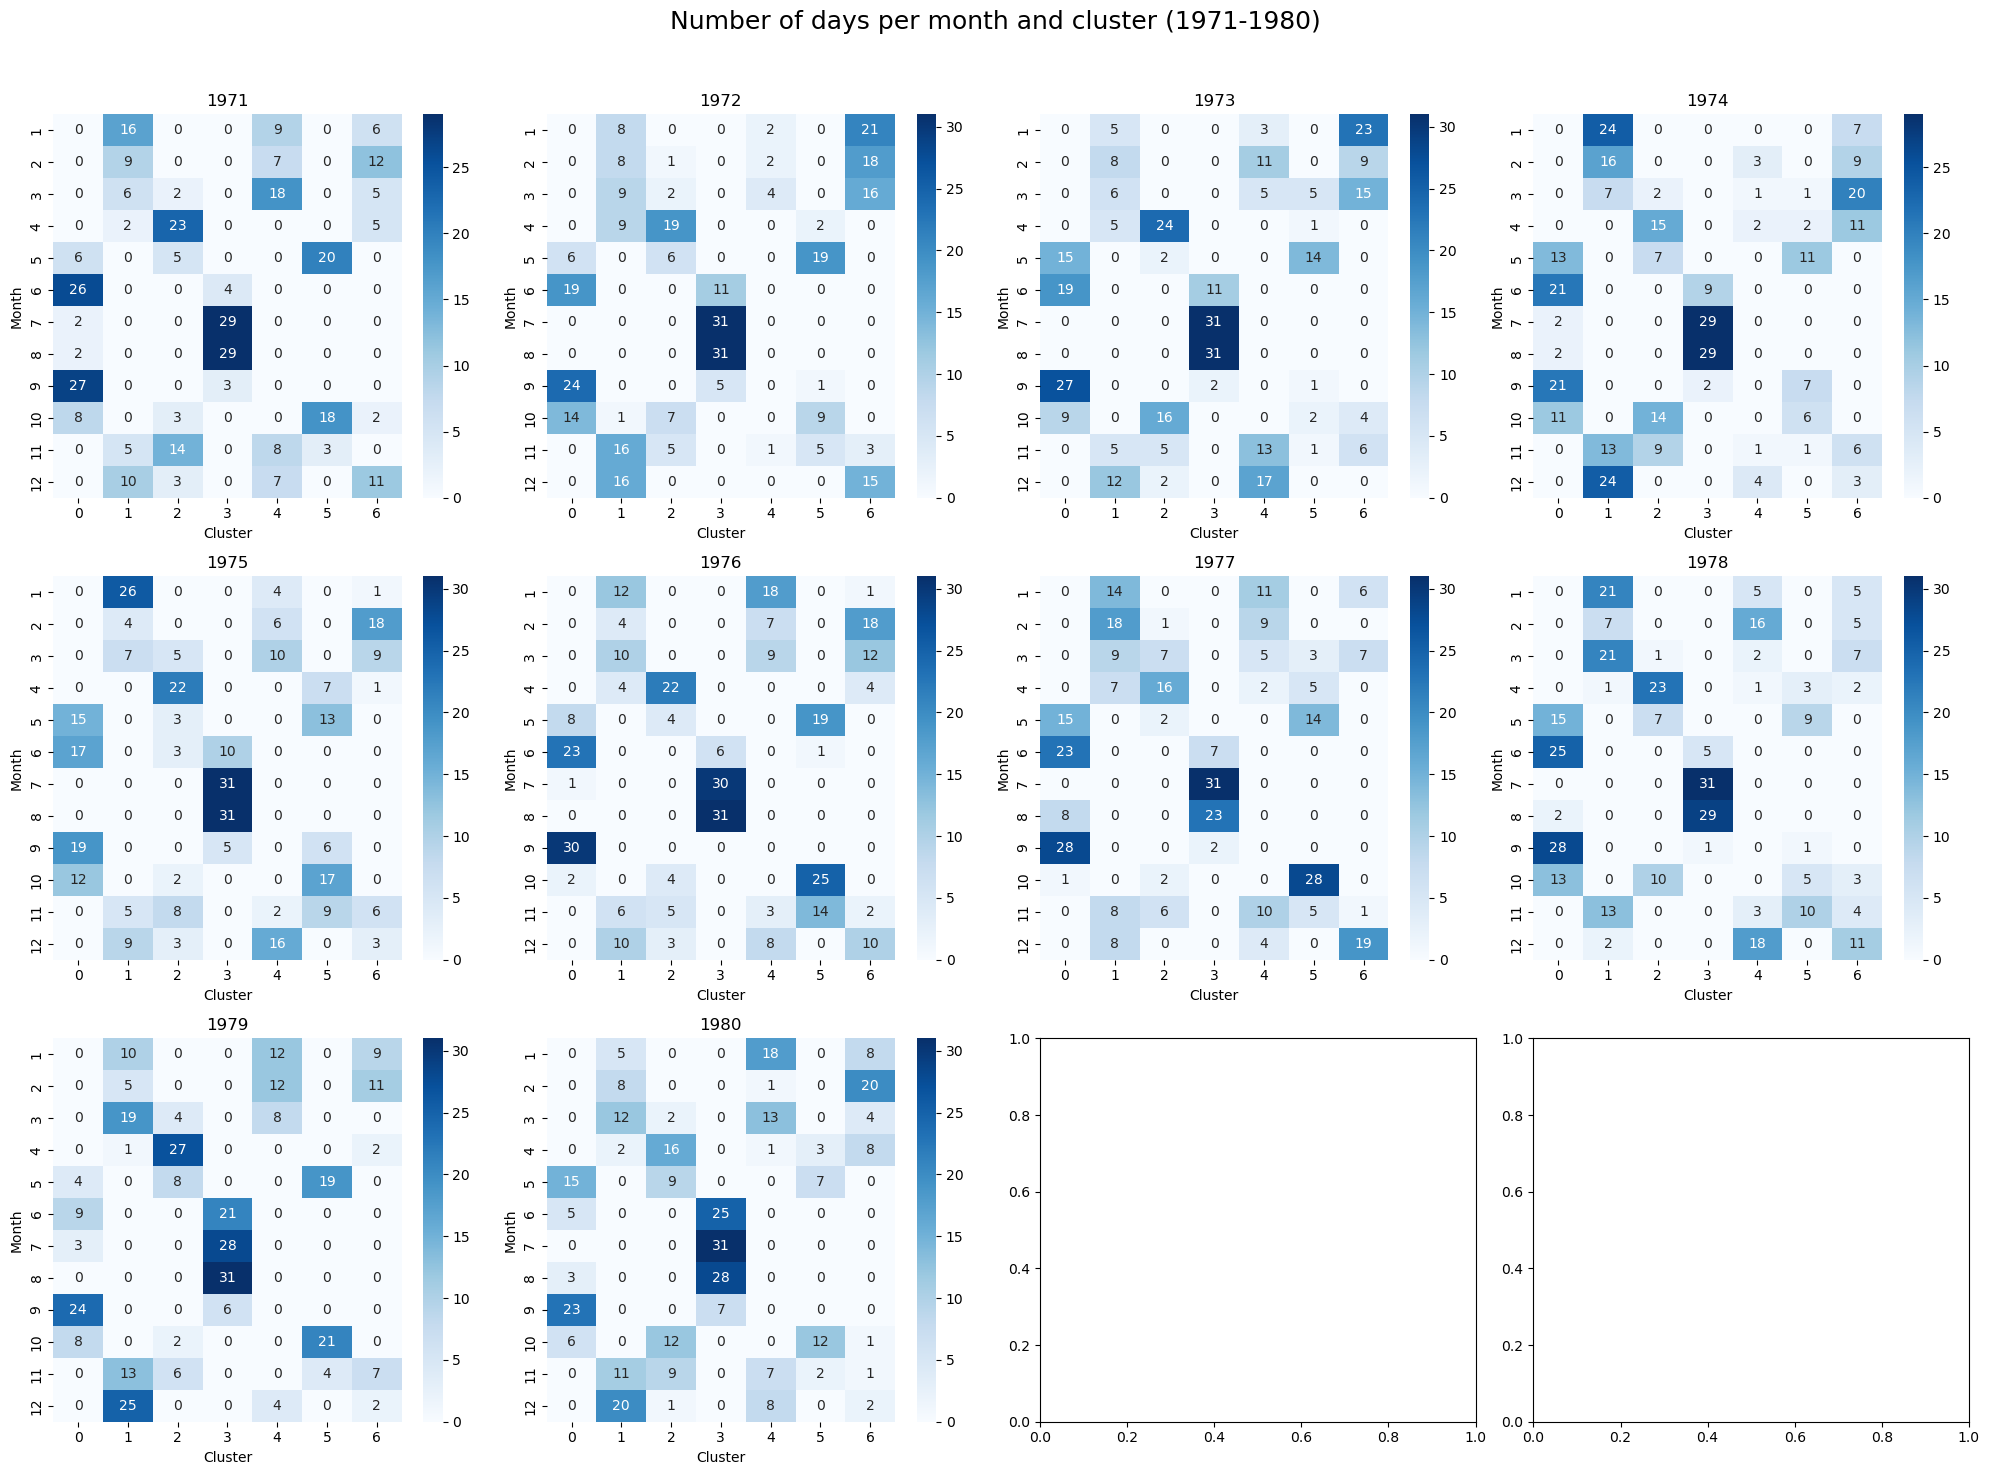

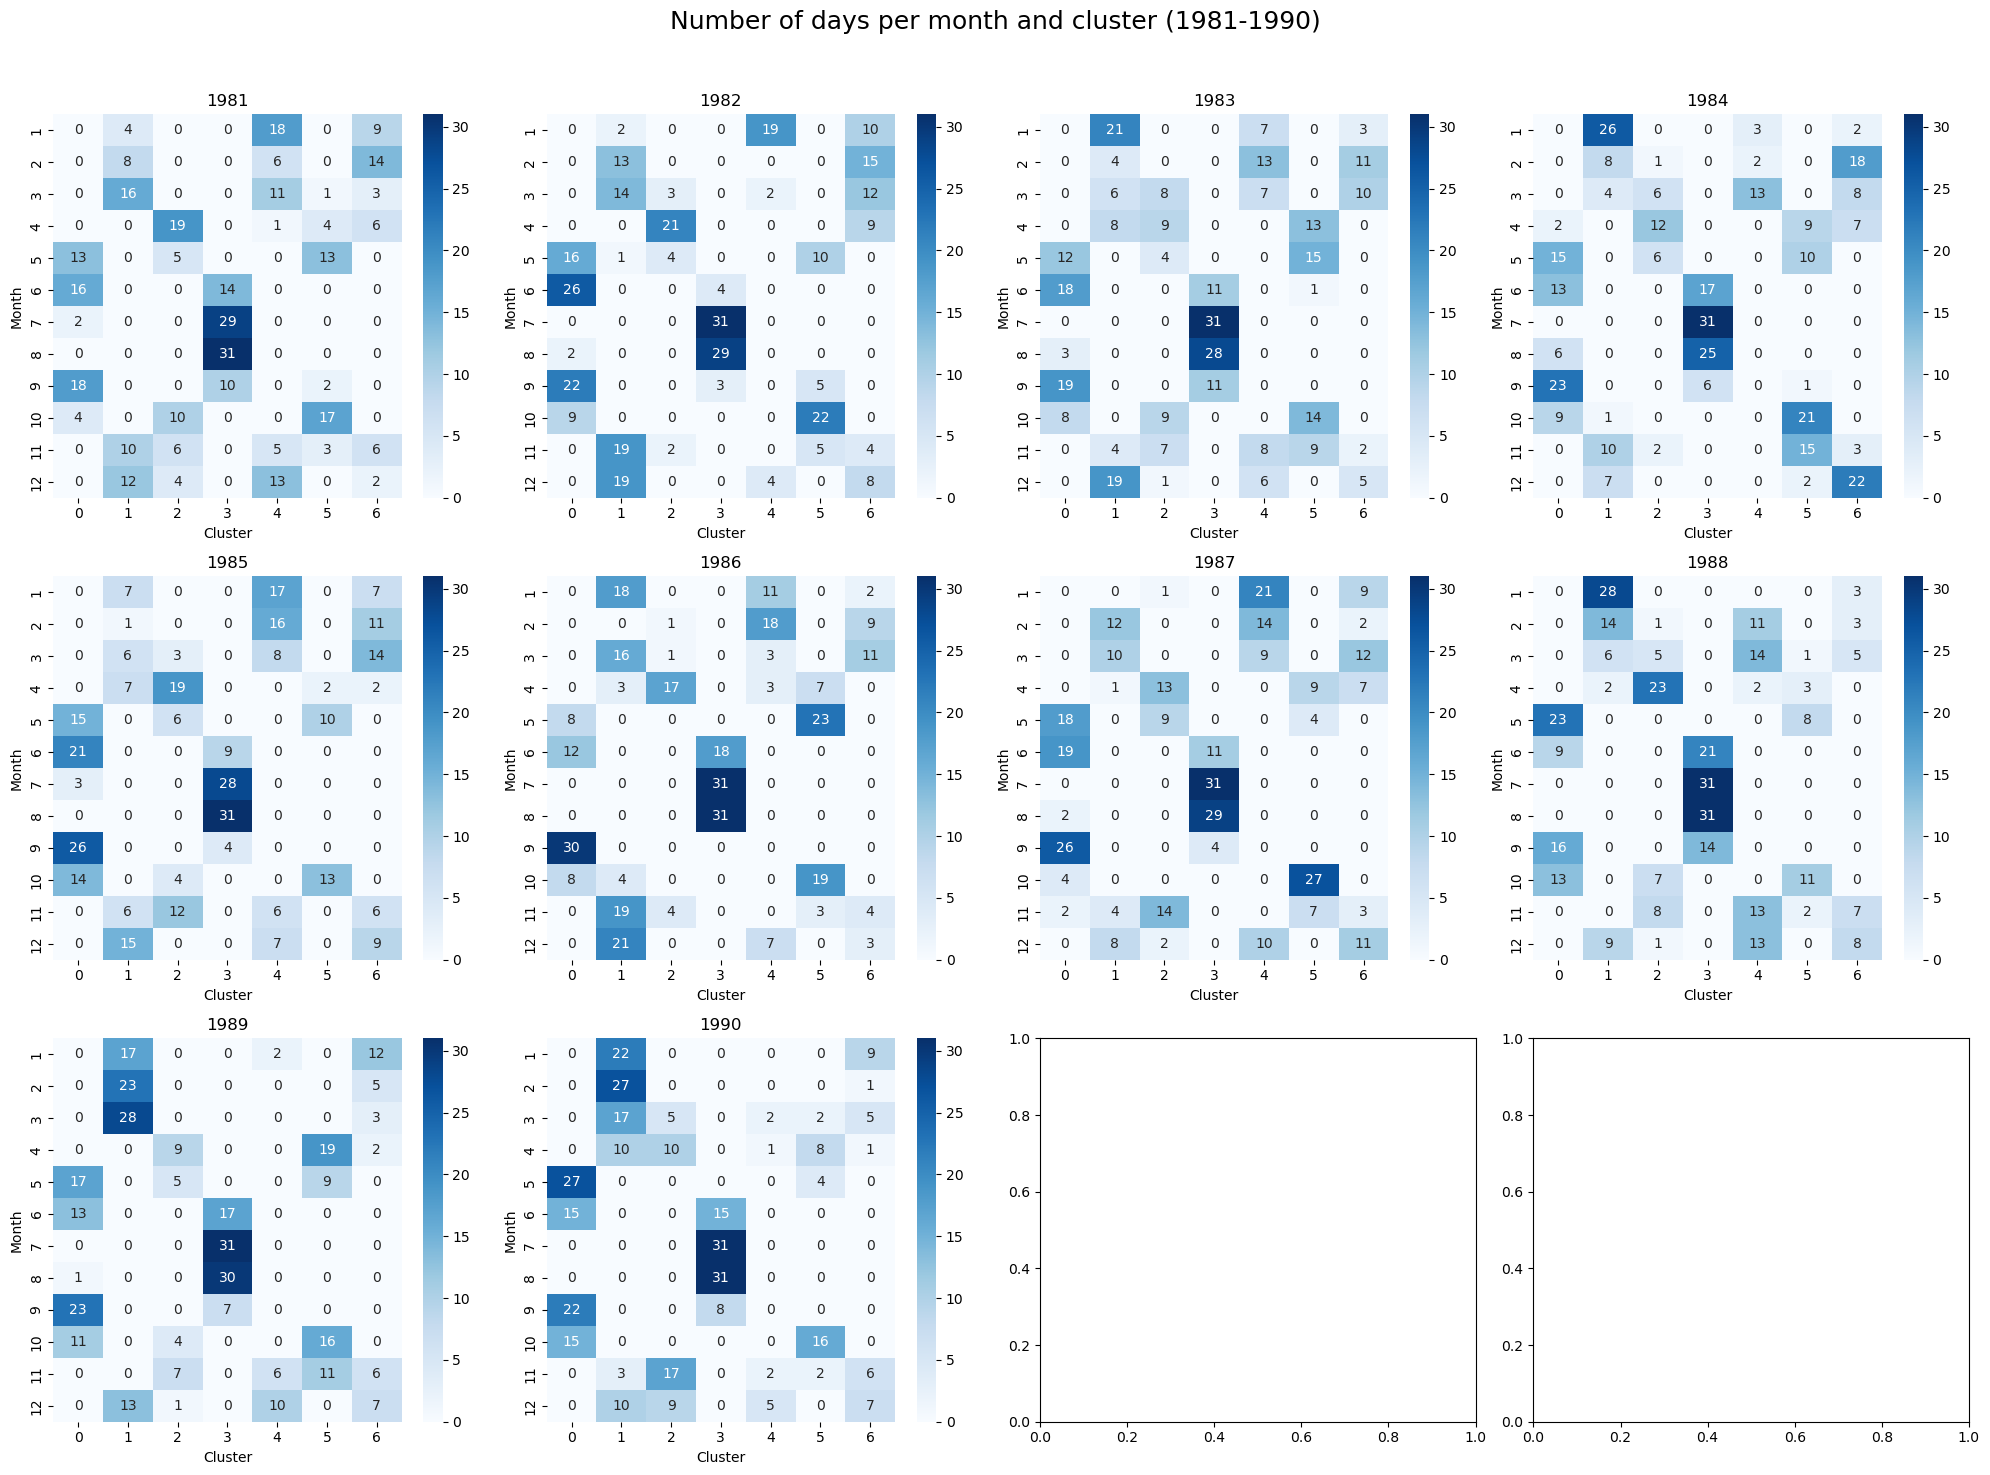

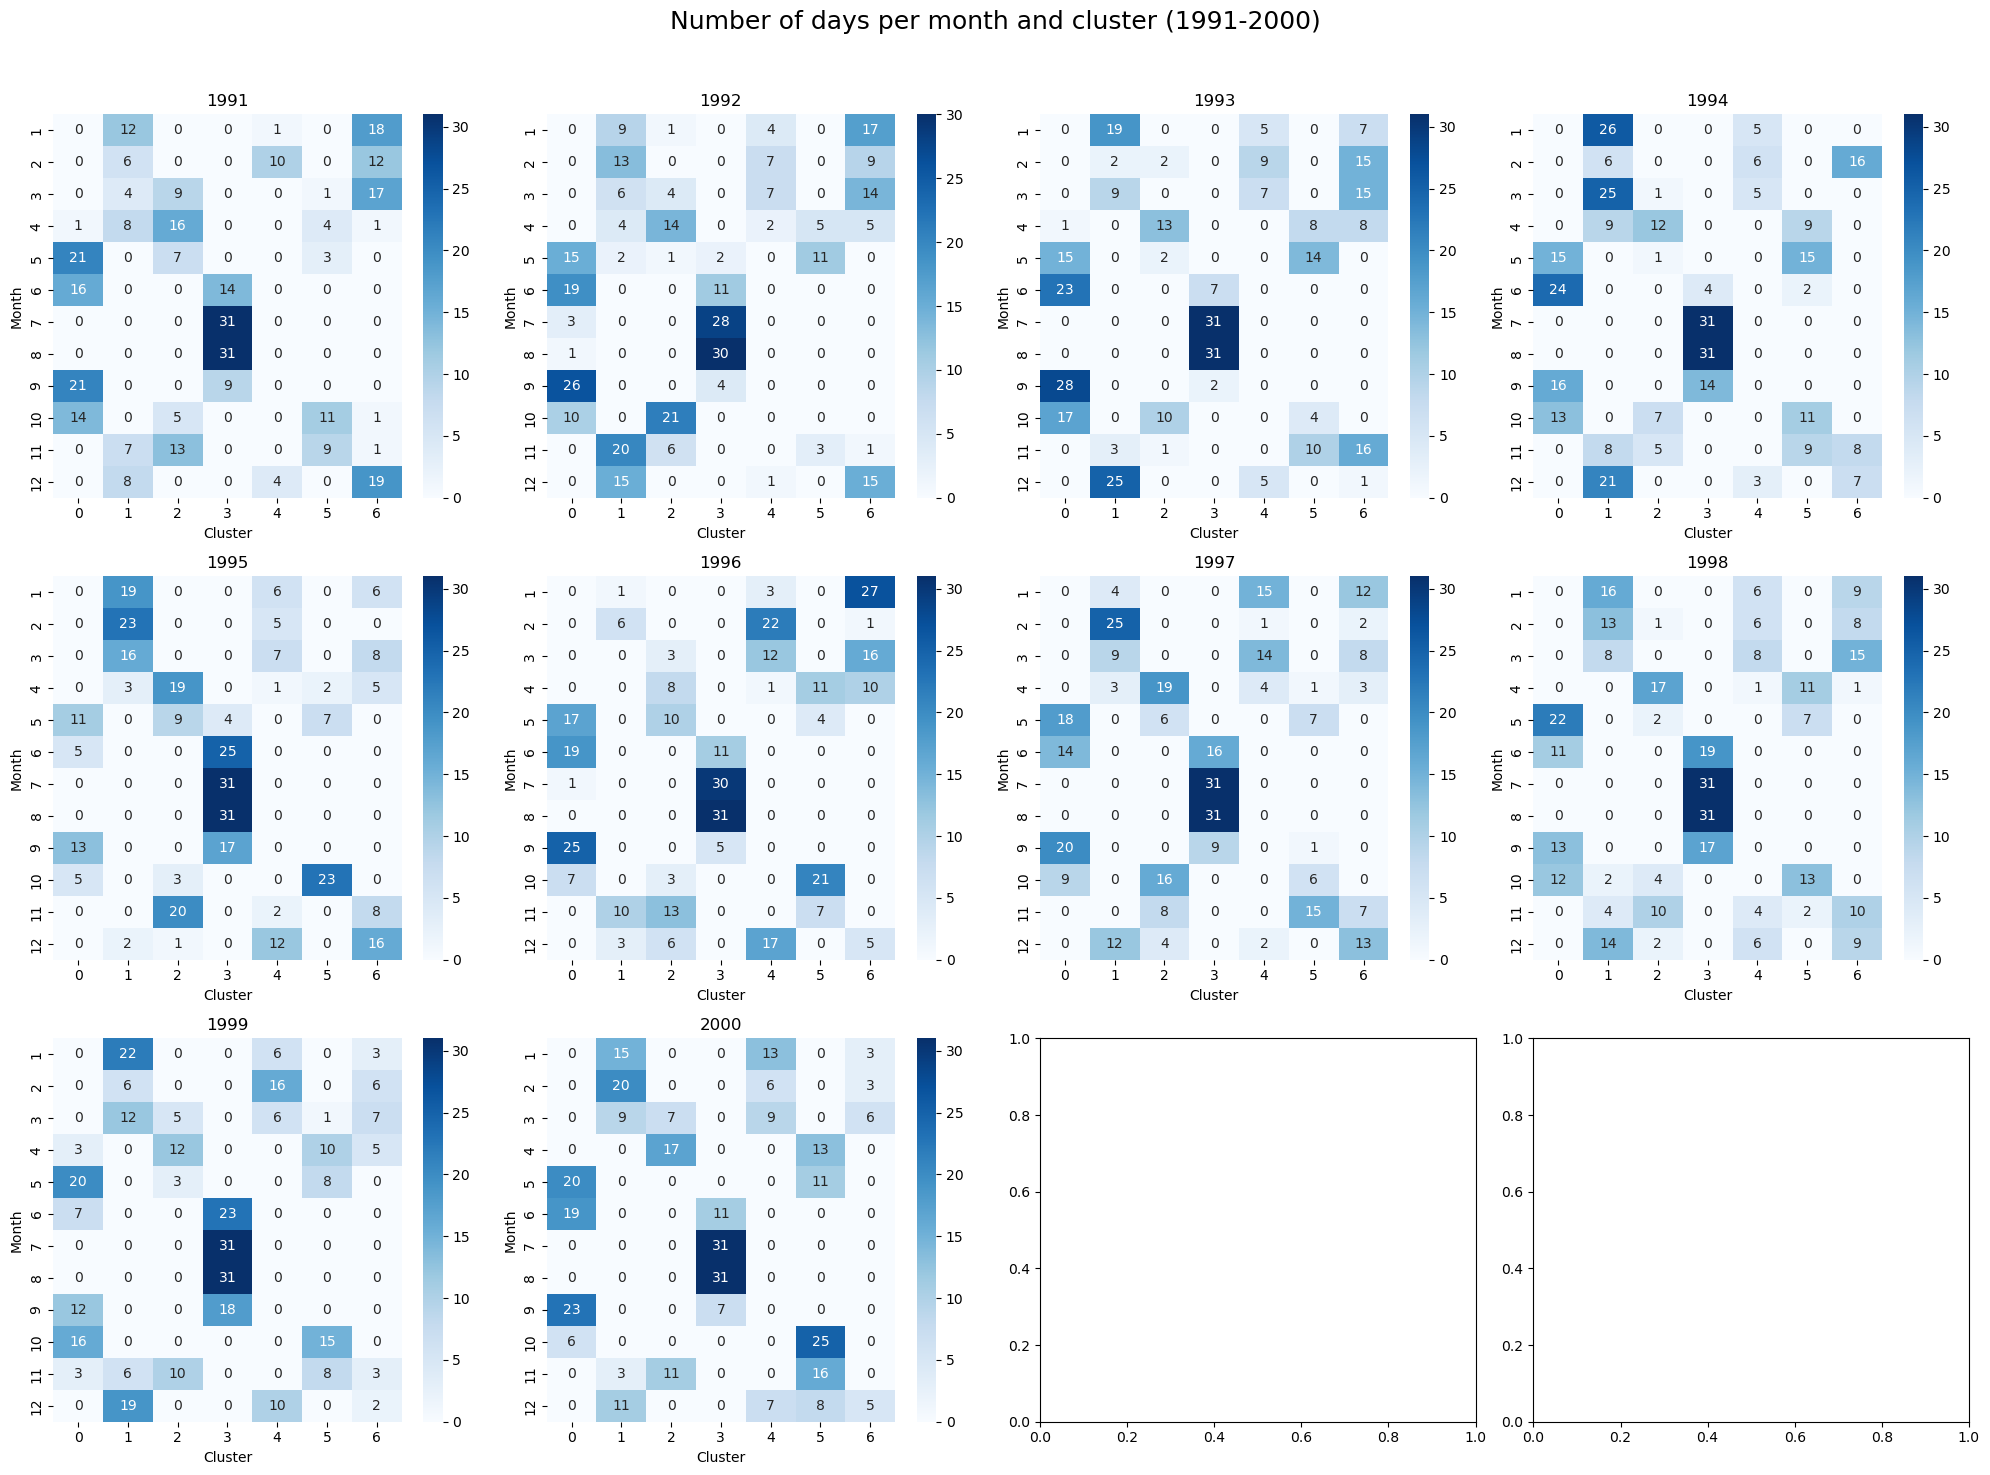

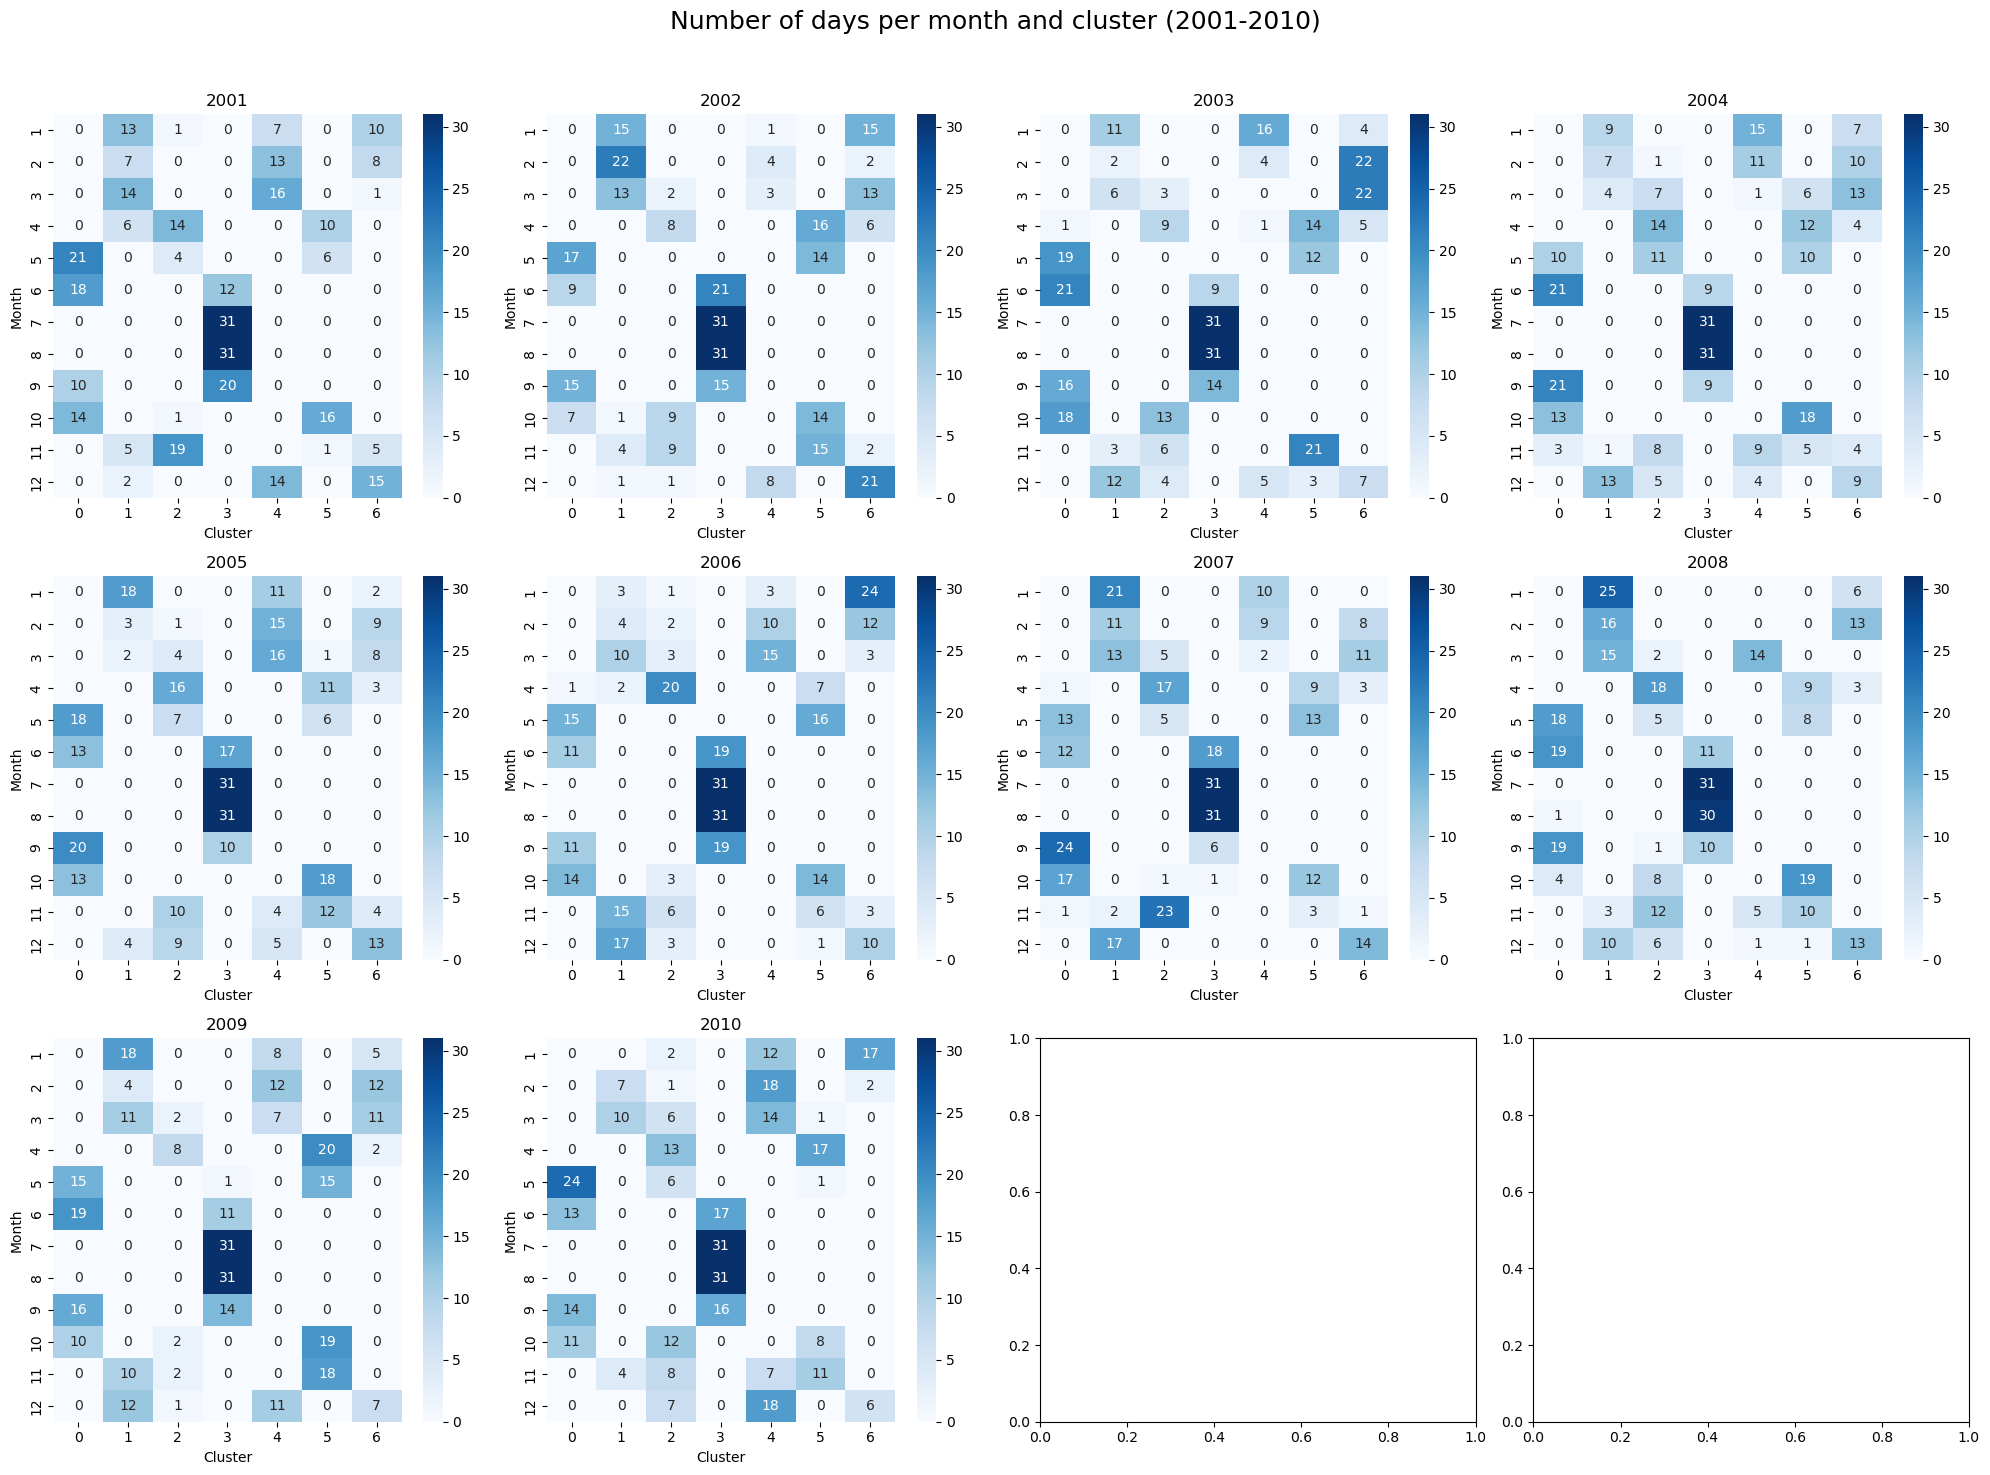

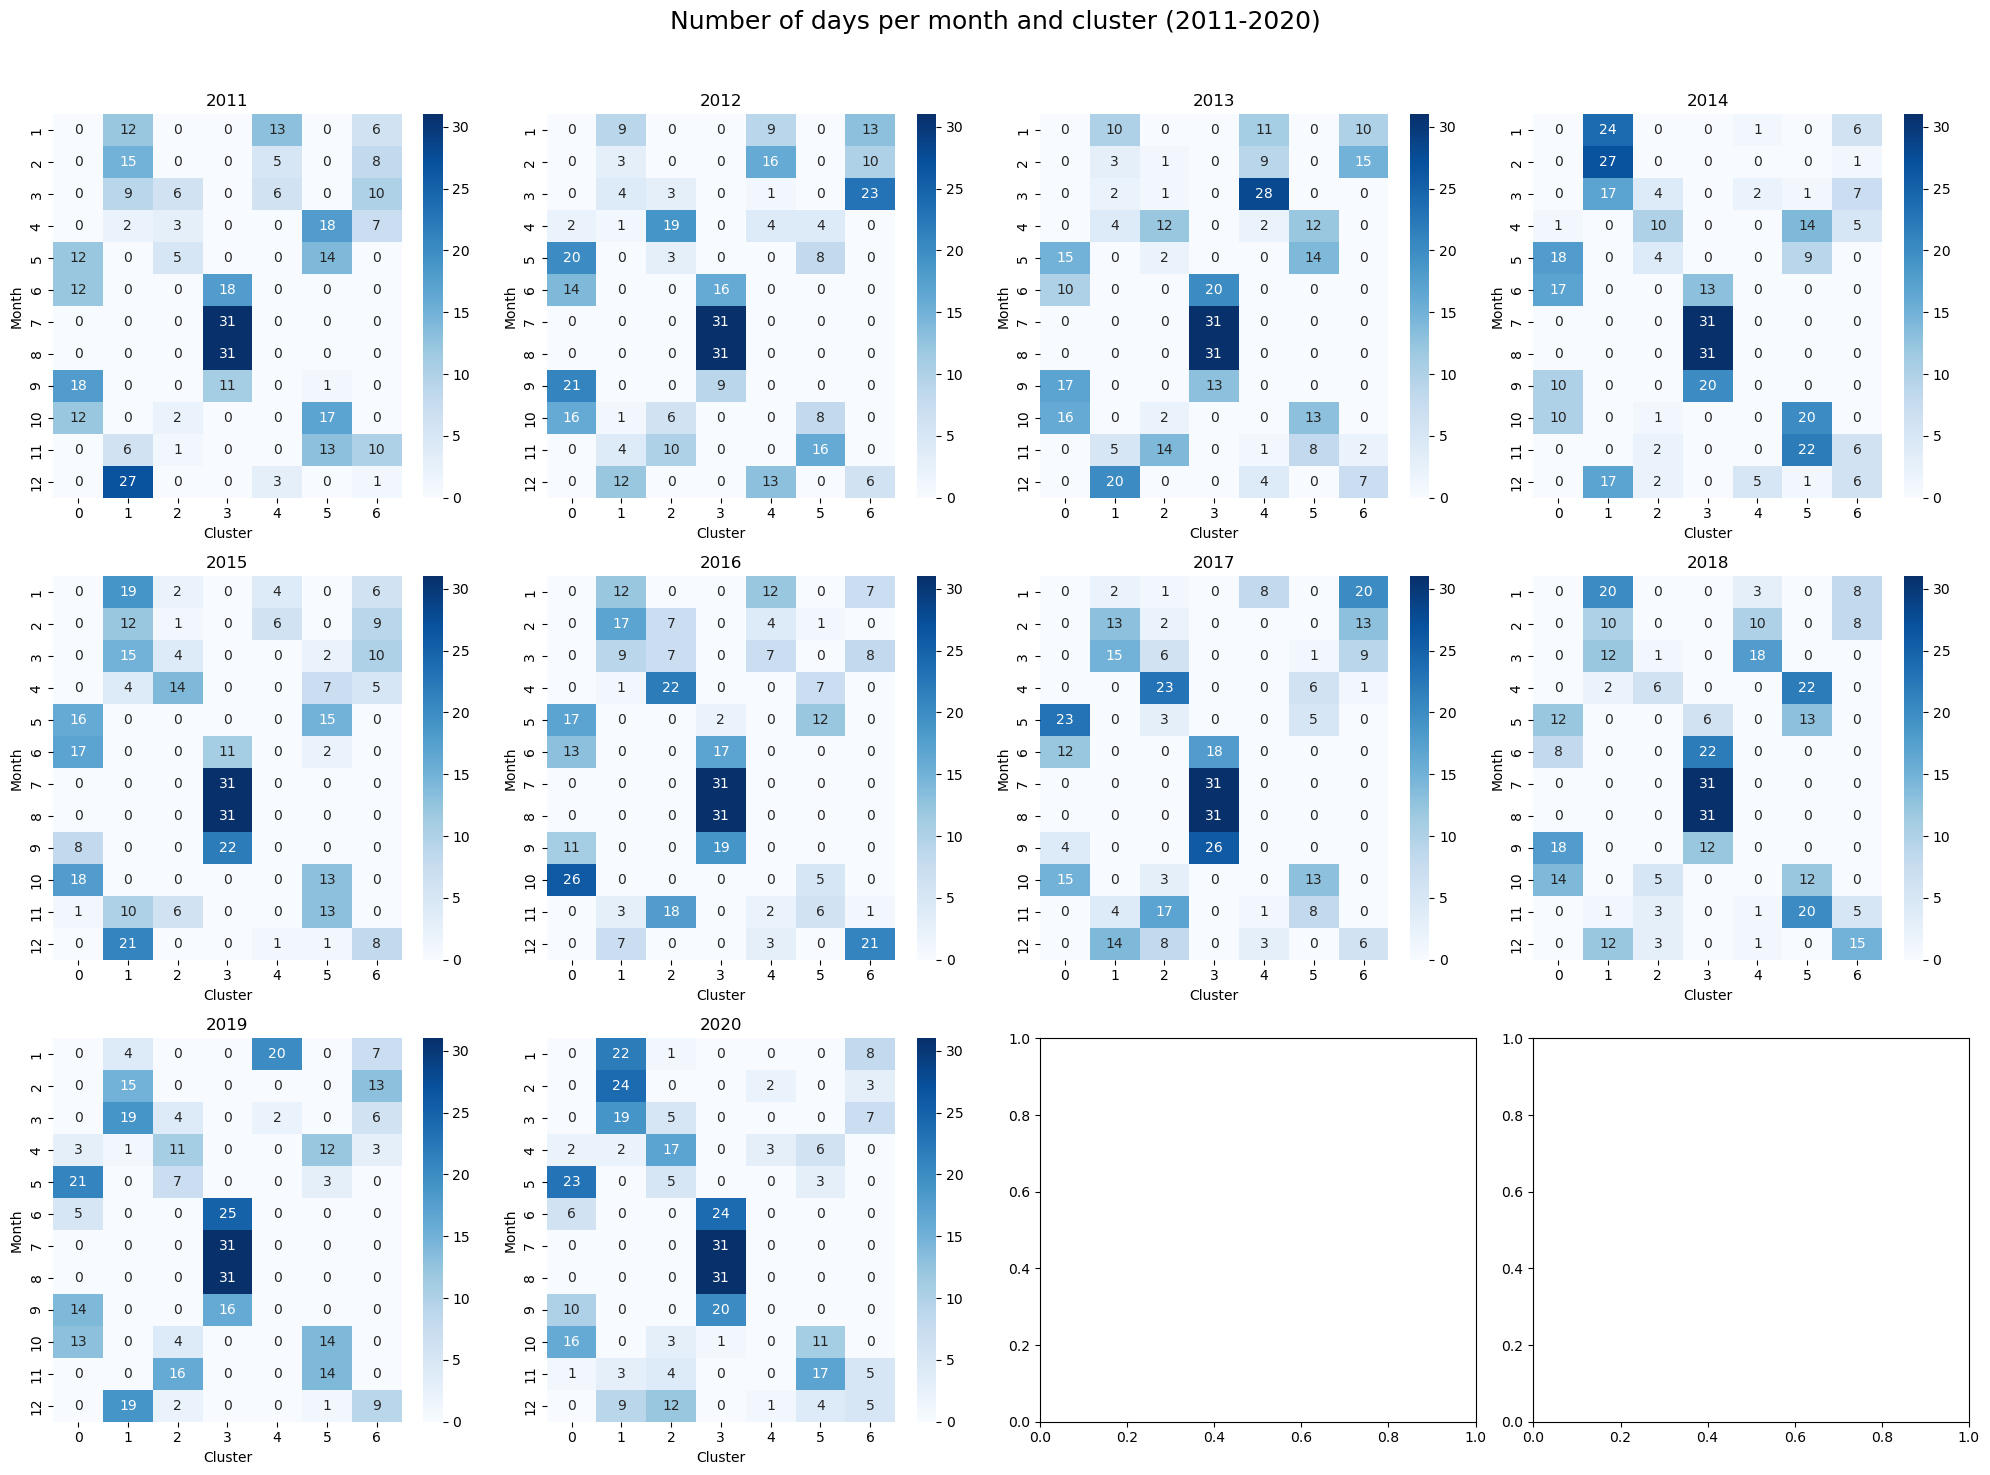

In [11]:
# Create a pivot table per year and month
pivot_table_year = pd.crosstab(
    [df_all['year'], df_all['month']],
    df_all['cluster']
)
print(pivot_table_year)
pivot_table_year.to_csv(f"Mid_result_to_save/tab_year_month_k{k_number}.csv")

# Decade ranges
decade_ranges = [(1961,1970), (1971,1980), (1981,1990), (1991,2000), (2001,2010), (2011,2020)]

for start, end in decade_ranges:
    years_in_decade = list(range(start, end+1))
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    for idx, year in enumerate(years_in_decade):
        if year in pivot_table_year.index.get_level_values(0):
            data = pivot_table_year.loc[year]
            ax = axes[idx]
            sns.heatmap(data, annot=True, fmt='d', cmap='Blues', ax=ax)
            ax.set_title(f'{year}')
            ax.set_xlabel('Cluster')
            ax.set_ylabel('Month')
            ax.set_yticks(np.arange(12)+0.5)
            ax.set_yticklabels([str(m) for m in range(1, 13)])
        else:
            fig.delaxes(axes[idx])
    plt.suptitle(f'Number of days per month and cluster ({start}-{end})', fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

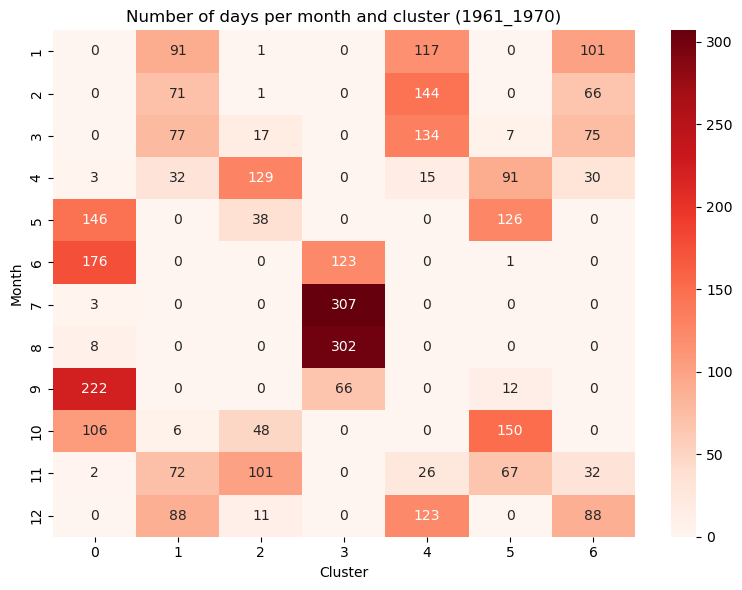

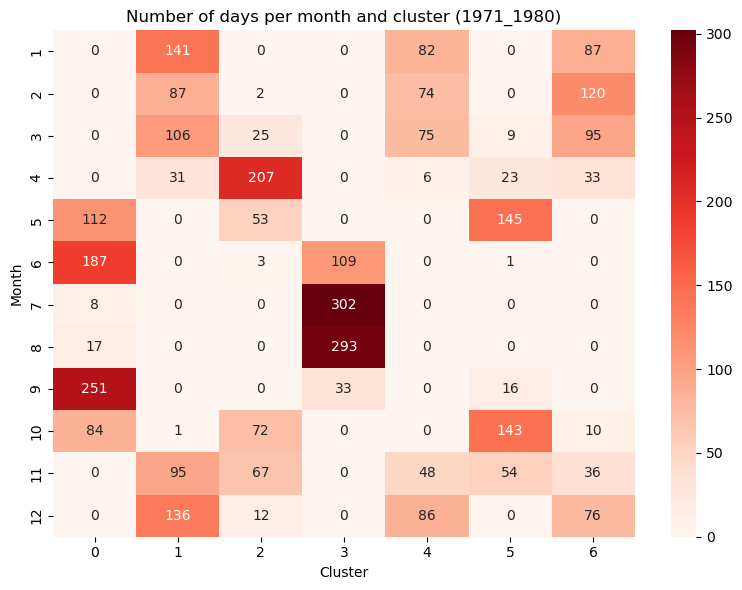

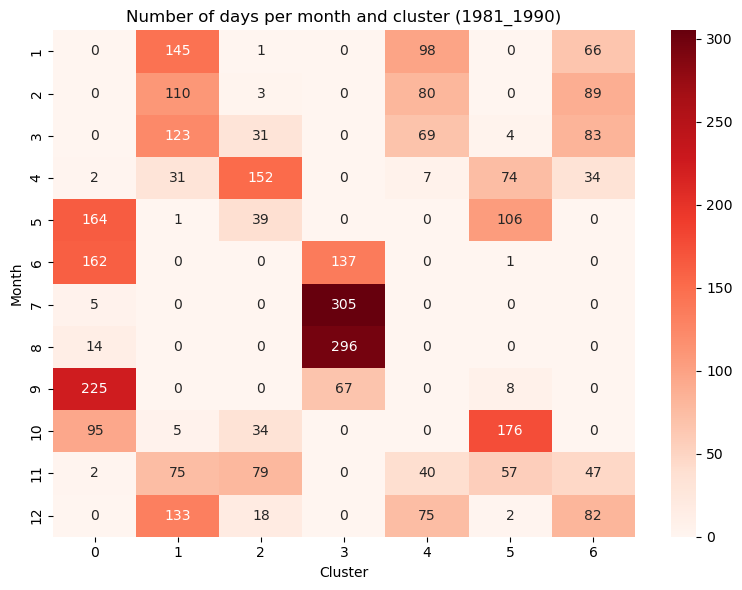

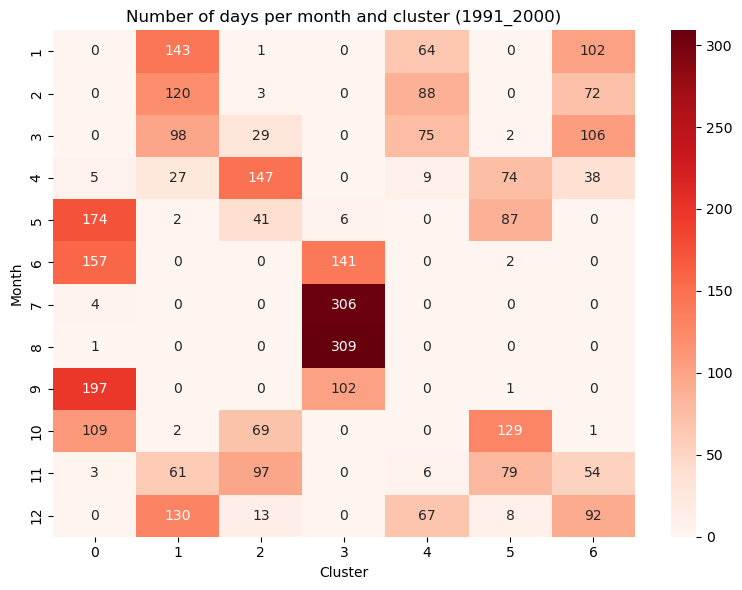

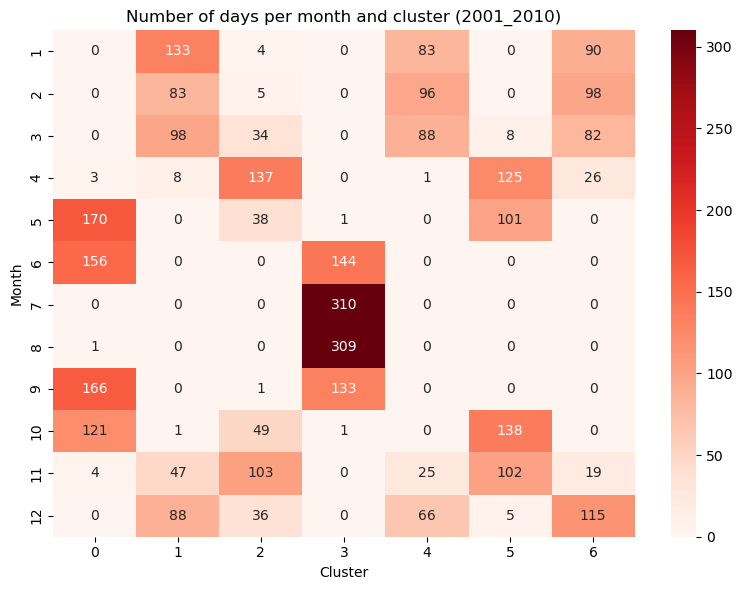

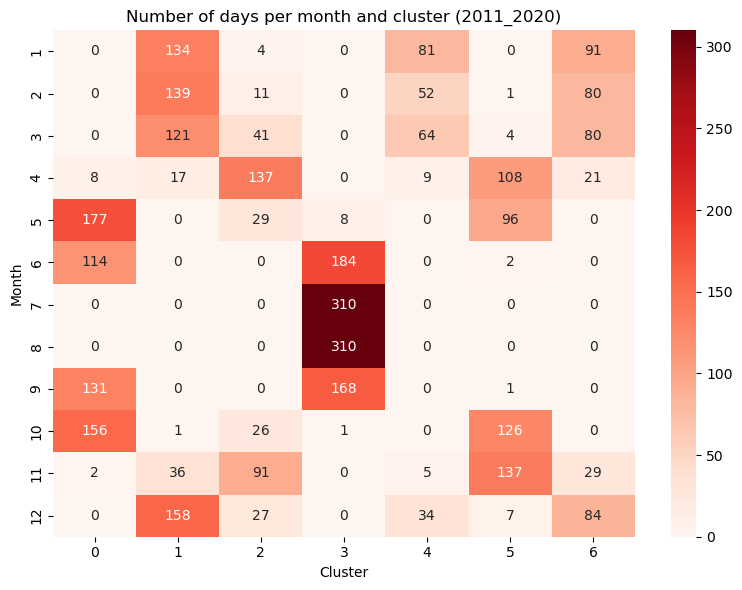

In [12]:
pivot_reset = pivot_table.reset_index()

# Heatmaps for each period
for period in pivot_table.index.get_level_values(0).unique():
    data = pivot_table.loc[period]
    plt.figure(figsize=(8, 6))
    sns.heatmap(data, annot=True, fmt='d', cmap='Reds')
    plt.title(f'Number of days per month and cluster ({period})')
    plt.xlabel('Cluster')
    plt.ylabel('Month')
    plt.yticks(ticks=np.arange(12)+0.5, labels=[str(m) for m in range(1, 13)])
    plt.tight_layout()
    plt.show()

Same tabs but not for each decade but per year

_________________________________12/09/2025 - colloquio prof

            Cluster 0   Cluster 1   Cluster 2   Cluster 3   Cluster 4  \
Decade                                                                  
1961_1970  132.738340  142.794572  151.307005  107.795308  155.615657   
1971_1980  131.836543  145.410880  146.438505  108.566324  156.366985   
1981_1990  134.959892  149.458621  148.232166  109.776169  157.408399   
1991_2000  136.352473  143.605558  152.149804  109.492631  155.215871   
2001_2010  130.700499  142.134850  148.477538  110.458964  155.132830   
2011_2020  138.000343  143.957214  149.289247  111.136523  150.146171   

            Cluster 5   Cluster 6  
Decade                             
1961_1970  136.420962  151.709750  
1971_1980  139.336822  153.748972  
1981_1990  143.115329  152.419465  
1991_2000  140.629677  154.828938  
2001_2010  141.348766  145.965841  
2011_2020  141.341360  155.075366  


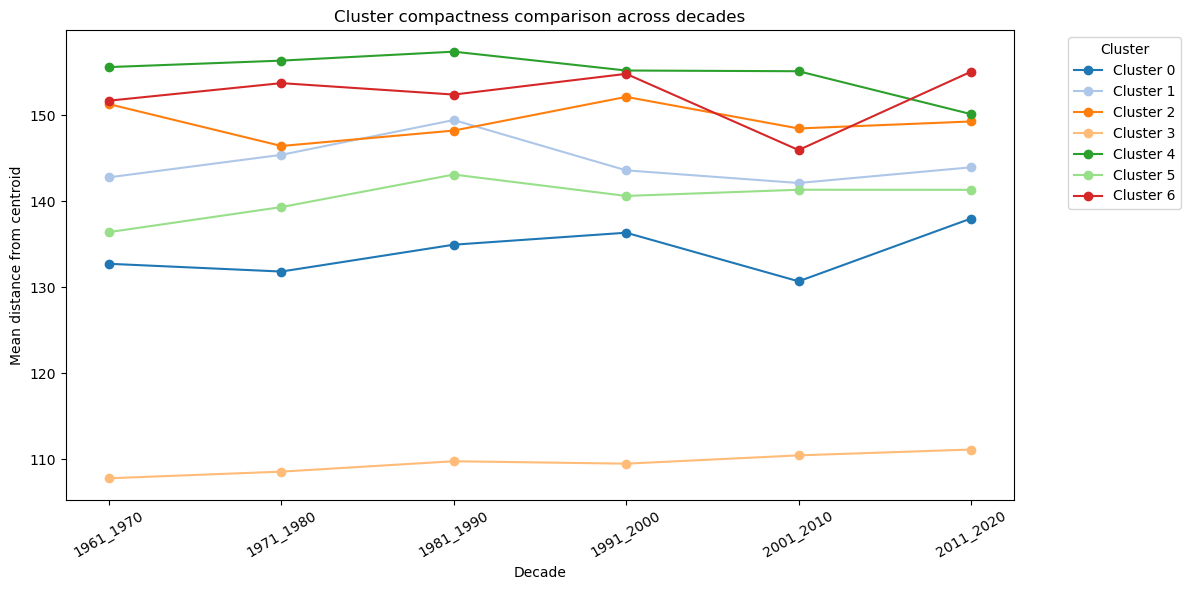

In [13]:
# Calculate mean distances to centroids for each cluster in each decade
def mean_distances_to_centroids(X_pca, labels, centroids):
    """Restituisce la distanza media di ogni cluster dal proprio centroide."""
    results = []
    for k in range(centroids.shape[0]):
        mask = labels == k
        if np.sum(mask) > 0:
            dists = np.linalg.norm(X_pca[mask] - centroids[k], axis=1)
            results.append(dists.mean())
    return results


mean_dists_per_decade = []
for decade in period_names:
    X_pca = np.load(f"Mid_result_to_save/X_pca_{decade}.npy")  
    labels = np.load(f"Mid_result_to_save/labels_{decade}.npy")
    dists = mean_distances_to_centroids(X_pca, labels, centroids)
    mean_dists_per_decade.append(dists)

# Create DataFrame
df_decades = pd.DataFrame(mean_dists_per_decade, columns=[f"Cluster {i}" for i in range(centroids.shape[0])])
df_decades["Decade"] = period_names
df_decades = df_decades.set_index("Decade")
print(df_decades)

# Plot compactness cluster as line plot
fig, ax = plt.subplots(figsize=(12,6))
for i, cluster in enumerate(df_decades.columns):
    ax.plot(df_decades.index, df_decades[cluster], color=plt.cm.tab20(i), marker='o', label=cluster)
ax.set_ylabel('Mean distance from centroid')
ax.set_xlabel('Decade')
ax.set_title('Cluster compactness comparison across decades')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1869/1725477722.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(decade_names))


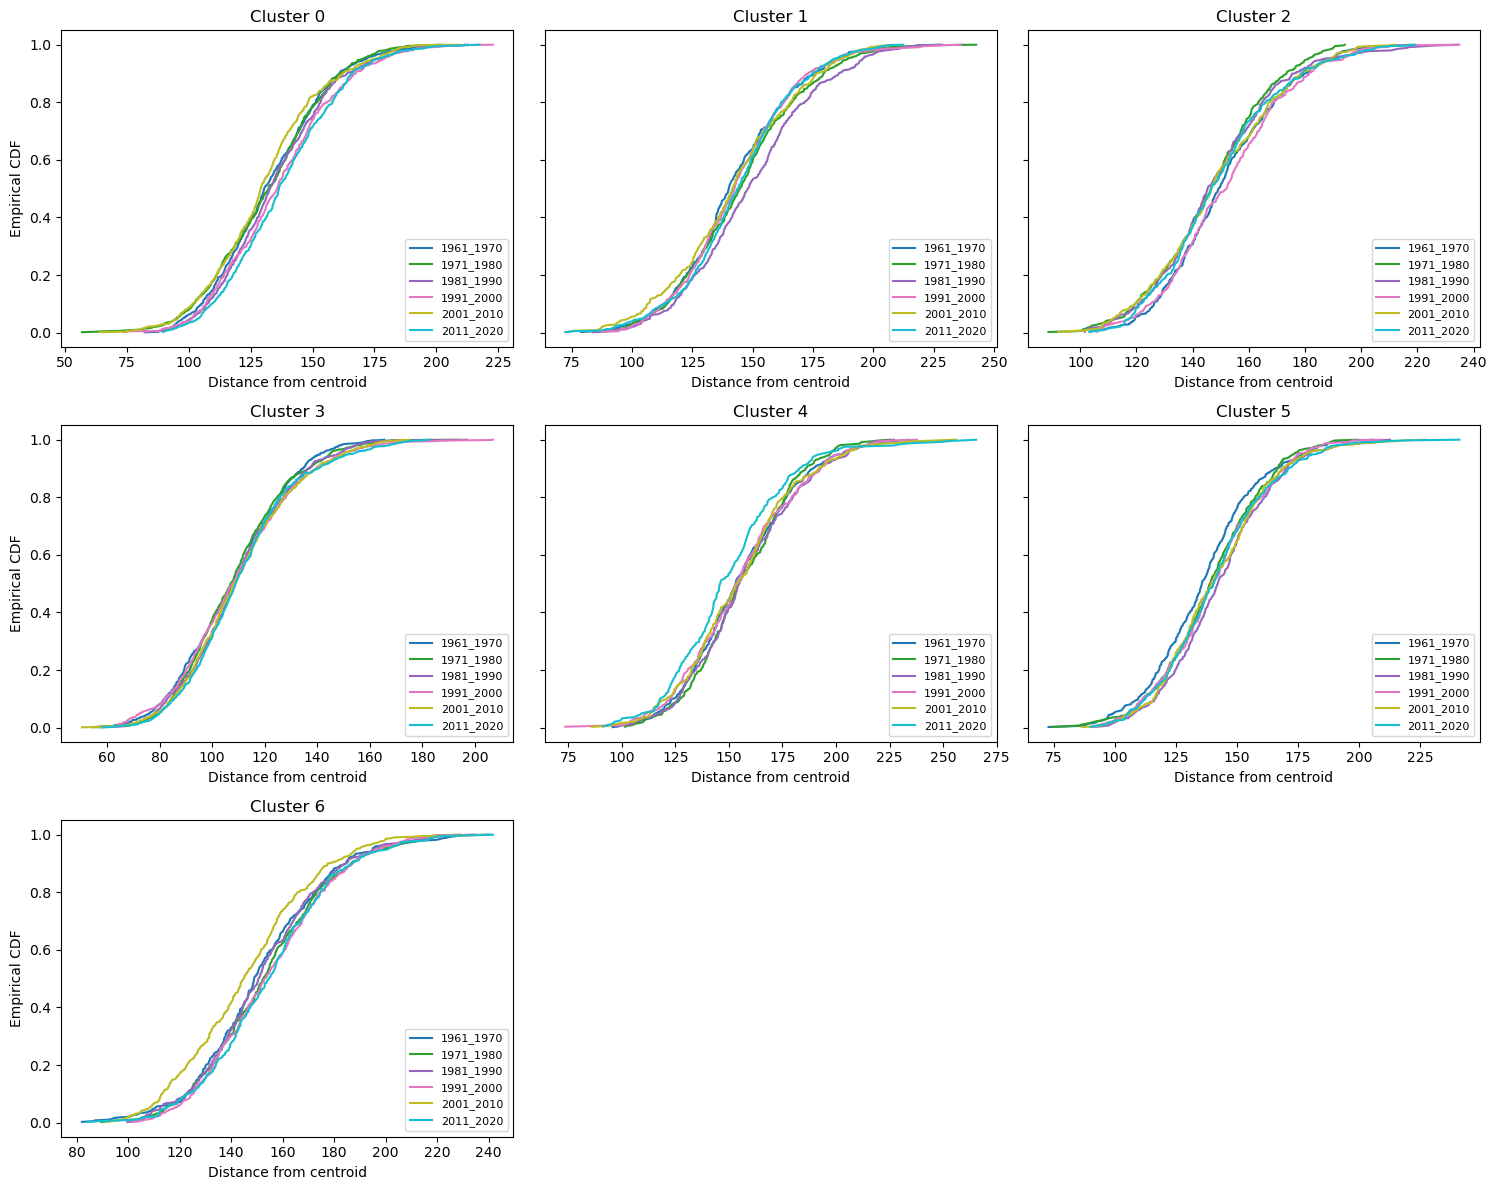

In [14]:
# Plot CDF of distances from centroid for each cluster and decade
def plot_cdf_distances_decades(decade_names, centroids):
    k_clusters = centroids.shape[0]
    n_cols = 3
    n_rows = int(np.ceil(k_clusters / n_cols))
    colors = plt.cm.get_cmap('tab10', len(decade_names))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharey=True)
    axes = axes.flatten()
    for k in range(k_clusters):
        ax = axes[k]
        for i, decade in enumerate(decade_names):
            X_pca = np.load(f"Mid_result_to_save/X_pca_{decade}.npy")
            labels = np.load(f"Mid_result_to_save/labels_{decade}.npy")
            mask = labels == k
            if np.sum(mask) > 0:
                dists = np.linalg.norm(X_pca[mask] - centroids[k], axis=1)
                sorted_dists = np.sort(dists)
                cdf = np.arange(1, len(sorted_dists)+1) / len(sorted_dists)
                ax.plot(sorted_dists, cdf, color=colors(i), label=decade)
        ax.set_title(f'Cluster {k}')
        ax.set_xlabel('Distance from centroid')
        if k % n_cols == 0:
            ax.set_ylabel('Empirical CDF')
        ax.legend(loc='lower right', fontsize=8)
    for j in range(k_clusters, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

# Use
plot_cdf_distances_decades(period_names, centroids)

Ora vediamo la silhouette --> misura quanto ogni punto è ben asseganto al proprio cluster rispetto agli altri cluster

In [15]:
# Mean silhouette 
silhouette_means = []
silhouette_clusters = []

for period in period_names:
    X_pca = np.load(f"Mid_result_to_save/X_pca_{period}.npy")
    labels = np.load(f"Mid_result_to_save/labels_{period}.npy")
    sil_mean = silhouette_score(X_pca, labels)
    silhouette_means.append(sil_mean)
    sil_samples = silhouette_samples(X_pca, labels)
    df = pd.DataFrame({'cluster': labels, 'silhouette': sil_samples})
    silhouette_clusters.append(df.groupby('cluster')['silhouette'].mean().values)


df_sil_means = pd.DataFrame({
    'Decade': period_names,
    'Mean Silhouette': silhouette_means
})
print(df_sil_means)

# Tab mean silhouette
df_sil_clusters = pd.DataFrame(silhouette_clusters, columns=[f'Cluster {i}' for i in range(len(silhouette_clusters[0]))])
df_sil_clusters['Decade'] = period_names
df_sil_clusters = df_sil_clusters.set_index('Decade')
print(df_sil_clusters)

# Plot mean silhouette per decade
df_sil_means.set_index('Decade').plot(kind='bar', figsize=(8,5), legend=False)
plt.ylabel('Mean silhouette score')
plt.title('Mean silhouette score per decade')
plt.tight_layout()
plt.show()

# Plot mean silhouette per cluster e decade
df_sil_clusters.plot(kind='bar', figsize=(12,6), colormap='tab20')
plt.ylabel('Mean silhouette score')
plt.title('Cluster silhouette comparison across decades')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'silhouette_score' is not defined